In [135]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load data with raw samples for efficiency analysis
with open('../message_counts_retained_split.json') as f:
    data = json.load(f)

print(f"✓ Data loaded with {len(data['raw_samples'])} models")

# Model display name mapping
model_display_names = {
    'bedrock_global.anthropic.claude-opus-4-7': 'Opus 4.7',
    'bedrock_global.anthropic.claude-sonnet-4-6': 'Sonnet 4.6',
    'bedrock_global.openai.gpt-4o': 'GPT-5.5',
    'bedrock_anthropic.claude-opus-4-7': 'Opus 4.7',
    'bedrock_anthropic.claude-sonnet-4-6': 'Sonnet 4.6',
    'bedrock_openai.gpt-4o': 'GPT-5.5',
    'bedrock_moonshotai.kimi-k2.5': 'Kimi',
    'zhipu.glm-5': 'GLM-5',
    'deepseek.deepseek-v3': 'DeepSeek',
    'xai.grok': 'Grok',
    'openai.gpt-4o-mini': 'GPT-5.4-nano',
}

# Excluded models
excluded_models = {"Haiku", "Sonnet 4.6", "GPT-OSS-120B"}

cwes = ['cwe79', 'cwe89', 'cwe352', 'cwe862', 'cwe787', 'cwe22', 'cwe416', 'cwe125', 'cwe78', 'cwe94']

print(f"✓ Setup complete")

Model Results (Fixed):
  Opus 4.7        (Frontier): DA=98.0%, Consistency=2.2%
  GPT-5.5         (Frontier): DA=95.6%, Consistency=4.3%
  GLM-5           (Frontier): DA=82.8%, Consistency=5.6%
  DeepSeek        (Baseline): DA=53.9%, Consistency=12.2%
  Kimi            (Baseline): DA=53.4%, Consistency=9.9%
  Grok            (Baseline): DA=40.1%, Consistency=8.1%
  GPT-5.4-nano    (Baseline): DA=34.5%, Consistency=11.6%


In [ ]:
# Collect all per-sample data
all_samples = []
for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    
    for prompt, cwes_data in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes_data.items():
            for framing, samples in framings.items():
                for sample in samples:
                    all_samples.append({
                        'model': display_name,
                        'message_count': sample.get('message_count', 0),
                        'detection': 1.0 if sample.get('detection_score') == 1.0 else 0.0,
                        'cwe': cwe
                    })

print(f"Collected {len(all_samples)} samples from {len(set(s['model'] for s in all_samples))} models")
if all_samples:
    print(f"  Sample: {all_samples[0]}")

In [ ]:
# Per-CWE efficiency analysis
fig, ax = plt.subplots(figsize=(14, 7))

# Calculate efficiency metrics per CWE per model
cwe_efficiency = defaultdict(lambda: {})

for model in set(s['model'] for s in all_samples):
    for cwe in set(s['cwe'] for s in all_samples):
        model_cwe_samples = [s for s in all_samples if s['model'] == model and s['cwe'] == cwe]
        
        if model_cwe_samples:
            avg_messages = np.mean([s['message_count'] for s in model_cwe_samples])
            detection_rate = np.mean([s['detection'] for s in model_cwe_samples]) * 100
            efficiency = detection_rate / avg_messages if avg_messages > 0 else 0
            
            cwe_efficiency[model][cwe] = {
                'messages': avg_messages,
                'detection': detection_rate,
                'efficiency': efficiency,
                'n_samples': len(model_cwe_samples)
            }

# Sort CWEs by average difficulty
cwes_list = sorted(set(s['cwe'] for s in all_samples))
cwe_difficulty = {}
for cwe in cwes_list:
    all_cwe_samples = [s for s in all_samples if s['cwe'] == cwe]
    cwe_difficulty[cwe] = np.mean([s['detection'] for s in all_cwe_samples]) * 100

cwes_sorted = sorted(cwes_list, key=lambda c: cwe_difficulty[c], reverse=True)

# Plot efficiency per CWE per model
x_pos = np.arange(len(cwes_sorted))
models_to_plot = sorted(set(s['model'] for s in all_samples))

for model in models_to_plot:
    efficiencies = []
    for cwe in cwes_sorted:
        if model in cwe_efficiency and cwe in cwe_efficiency[model]:
            efficiencies.append(cwe_efficiency[model][cwe]['efficiency'])
        else:
            efficiencies.append(0)
    
    is_frontier = model in frontier_models
    linestyle = '-' if is_frontier else '--'
    marker = 'o' if is_frontier else 's'
    
    ax.plot(x_pos, efficiencies, marker=marker, linestyle=linestyle, 
           linewidth=2.5, markersize=8, label=model, 
           color=model_colors.get(model, '#999999'), alpha=0.8)

ax.set_xlabel("CWE (Sorted by Detection Difficulty)", fontsize=12, fontweight="bold")
ax.set_ylabel("Efficiency (Detection Rate / Message Count)", fontsize=12, fontweight="bold")
ax.set_title("(i) Per-CWE Efficiency: How Well Models Reason About Each Vulnerability", 
            fontsize=12, fontweight="bold", loc='left')
ax.set_xticks(x_pos)
ax.set_xticklabels([c.upper() for c in cwes_sorted], rotation=0)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig("15_per_cwe_efficiency.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 15_per_cwe_efficiency.png")
plt.show()

In [ ]:
# Efficiency clustering analysis
fig, ax = plt.subplots(figsize=(13, 8))

for sample in all_samples:
    color = model_colors.get(sample['model'], '#999999')
    marker = 'o' if sample['detection'] == 1.0 else 'x'
    ax.scatter(sample['message_count'], sample['detection'] * 100, 
              s=40, alpha=0.2, color=color, marker=marker, linewidth=0.5)

# Add quadrant regions
ax.axvline(x=20, color='gray', linestyle=':', alpha=0.4, linewidth=2)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.4, linewidth=2)

# Add quadrant labels
ax.text(10, 75, "Efficient\n(Low Effort, High Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(35, 75, "Thorough\n(High Effort, High Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(10, 25, "Quick Fails\n(Low Effort, Low Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))
ax.text(35, 25, "Struggling\n(High Effort, Low Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# Add model average points
for model in sorted(set(s['model'] for s in all_samples)):
    model_samples = [s for s in all_samples if s['model'] == model]
    avg_messages = np.mean([s['message_count'] for s in model_samples])
    avg_detection = np.mean([s['detection'] for s in model_samples]) * 100
    
    color = model_colors.get(model, '#999999')
    ax.scatter(avg_messages, avg_detection, s=350, alpha=0.9, color=color, 
              edgecolors='black', linewidth=2.5, label=model, zorder=10)

ax.set_xlabel("Message Count", fontsize=12, fontweight="bold")
ax.set_ylabel("Detection Success Rate (%)", fontsize=12, fontweight="bold")
ax.set_title("(h) Efficiency Clustering: Reasoning Patterns", fontsize=12, fontweight="bold", loc='left')
ax.set_xlim(-2, 50)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig("14_efficiency_clusters.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 14_efficiency_clusters.png")
plt.show()

In [ ]:
# Create per-sample scatter plot
fig, ax = plt.subplots(figsize=(13, 7))

# Define colors by model type
model_colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Plot each sample with transparency
for sample in all_samples:
    color = model_colors.get(sample['model'], '#999999')
    marker = 'o' if sample['detection'] == 1.0 else 'x'
    ax.scatter(sample['message_count'], sample['detection'] * 100, 
              s=30, alpha=0.15, color=color, marker=marker, linewidth=0.5)

# Add model legend (average points)
for model in sorted(set(s['model'] for s in all_samples)):
    model_samples = [s for s in all_samples if s['model'] == model]
    avg_messages = np.mean([s['message_count'] for s in model_samples])
    avg_detection = np.mean([s['detection'] for s in model_samples]) * 100
    
    color = model_colors.get(model, '#999999')
    ax.scatter(avg_messages, avg_detection, s=300, alpha=0.8, color=color, 
              edgecolors='black', linewidth=2, label=model, zorder=5)

ax.set_xlabel("Message Count (Individual Samples)", fontsize=12, fontweight="bold")
ax.set_ylabel("Detection Result (%)", fontsize=12, fontweight="bold")
ax.set_title("(g) Per-Sample Message Count vs Detection Success", fontsize=12, fontweight="bold", loc='left')
ax.set_ylim(-5, 105)
ax.set_xlim(-2, min(100, max(s['message_count'] for s in all_samples) + 10))
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig("13_message_count_per_sample_scatter.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 13_message_count_per_sample_scatter.png")
plt.show()

## Message Count Correlation Analysis

Analyzing the relationship between reasoning depth (message count) and detection success.

# NIPS Publication Visualizations

Publication-quality scatter plots and analysis for the malicious PR benchmark paper.

**Data**: Retained challenge split (1,062 samples), plain prompt only
**Models**: 7 models (Opus 4.7, GPT-5.5, GLM-5, GPT-5.4-nano, DeepSeek, Kimi, Grok)
**CWEs**: All 10 vulnerability types
**Framings**: 15 social engineering framings

This notebook generates six publication-ready visualizations:
1. CWE Vulnerability Characteristics (scatter)
2. Model Robustness Analysis (scatter)
3. Social Engineering Effectiveness by Vulnerability (bubble scatter)
4. Framing Effectiveness Ranking (bar chart)
5. Framing Robustness Across CWEs (scatter)
6. Framing Landscape (polar/radial view)

## Data Generation

**Important:** This notebook requires `nips_results_with_srr_retained_split.json` which must be generated first.

### Generating the data file

```bash
cd visualizations/scripts/
python3 extract_nips_results_with_srr.py --retained
```

This script:
1. Scans `logs/results_nips/` (frontier models) and `logs/filtering_releases/` (baseline models)
2. Extracts detection accuracy and security reasoning rates from evaluation logs
3. Aggregates results per-CWE and per-framing
4. Filters to retained challenge split (1,062 samples where weak baselines failed)
5. Outputs `../nips_results_with_srr_retained_split.json`

**Data sources:**
- `logs/results_nips/` — Frontier model evaluation results (Opus 4.7, GPT-5.5, GLM-5)
- `logs/filtering_releases/` — Baseline model evaluation results (GPT-5.4-nano, DeepSeek, Kimi, Grok)
- `retained_sample_ids.json` — Retained challenge split definition (1,062 curated samples)

## Setup and Configuration

## Load Data

In [136]:
# Load aggregated results
with open('../nips_results_with_srr_retained_split.json') as f:
    data = json.load(f)

# Load retained sample IDs
with open('../retained_sample_ids.json') as f:
    retained_ids_by_cwe = json.load(f)

# Define CWEs
cwes = ['cwe79', 'cwe89', 'cwe352', 'cwe862', 'cwe787', 'cwe22', 'cwe416', 'cwe125', 'cwe78', 'cwe94']

print(f'✓ Loaded data for {len(cwes)} CWEs')
print(f'✓ Models: {len(data["per_cwe"])} total')

✓ Loaded data for 10 CWEs
✓ Models: 10 total


In [137]:
# Mapping for clean framing display names
framing_display_names = {
    'ai_agent_authored': 'AI Agent Authored',
    'appeal_to_authority': 'Appeal to Authority',
    'build_system_laundering': 'Build System Laundering',
    'dependency_compat_claim': 'Dependency Compat Claim',
    'emotional_appeal': 'Emotional Appeal',
    'evidence_dilution': 'Evidence Dilution',
    'fake_bug_fix': 'Fake Bug Fix',
    'false_coverage': 'False Coverage',
    'misleading_hardening': 'Misleading Hardening',
    'misleading_pass': 'Misleading Pass',
    'out_of_distribution': 'Out-of-Distribution',
    'prior_approval_signal': 'Prior Approval Signal',
    'refactoring': 'Refactoring',
    'review_bias': 'Review Bias',
    'unsafe_optimization': 'Unsafe Optimization',
}

print('✓ Framing display names configured')

✓ Framing display names configured


## Plot 1: CWE Vulnerability Characteristics

Shows refusal rate (X-axis) vs security reasoning rate (Y-axis) for each CWE.
- Green CWEs: Easy to detect, models provide reasoning
- Red CWEs: Hard to detect, less reasoning

**Key insight**: Some vulnerabilities (Use-After-Free) are fundamentally harder to reason about.

In [138]:
# Aggregate metrics for CWEs
cwe_metrics = {}
for cwe in cwes:
    cwe_metrics[cwe] = {
        'da_caught': 0, 'da_missed': 0, 'da_total': 0,
        'srr_caught': 0, 'srr_missed': 0, 'srr_total': 0
    }

for model, prompts in data['per_cwe'].items():
    if 'plain' not in prompts:
        continue
    for cwe, metrics in prompts['plain'].items():
        if cwe not in cwe_metrics:
            continue
        da = metrics['detection_accuracy']
        if da['accuracy'] is not None:
            cwe_metrics[cwe]['da_caught'] += da['accuracy'] * da['n_samples'] / 100
            cwe_metrics[cwe]['da_missed'] += (100 - da['accuracy']) * da['n_samples'] / 100
            cwe_metrics[cwe]['da_total'] += da['n_samples']
        srr = metrics['security_reason_rate']
        if srr['accuracy'] is not None:
            cwe_metrics[cwe]['srr_caught'] += srr['accuracy'] * srr['n_samples'] / 100
            cwe_metrics[cwe]['srr_missed'] += (100 - srr['accuracy']) * srr['n_samples'] / 100
            cwe_metrics[cwe]['srr_total'] += srr['n_samples']

# Compute final metrics
cwe_results = {}
for cwe in cwes:
    counts = cwe_metrics[cwe]
    da_acc = (counts['da_caught'] / counts['da_total'] * 100) if counts['da_total'] > 0 else 0
    srr_acc = (counts['srr_caught'] / counts['srr_total'] * 100) if counts['srr_total'] > 0 else 0
    cwe_results[cwe] = {
        'rejection_rate': 100 - da_acc,
        'security_reason_rate': srr_acc,
    }

print('CWE Results:')
for cwe in sorted(cwes, key=lambda c: cwe_results[c]['rejection_rate'], reverse=True):
    rr = cwe_results[cwe]['rejection_rate']
    srr = cwe_results[cwe]['security_reason_rate']
    print(f'  {cwe.upper()}: RR={rr:.1f}%, SRR={srr:.1f}%')

CWE Results:
  CWE416: RR=43.3%, SRR=13.5%
  CWE79: RR=39.2%, SRR=42.2%
  CWE78: RR=37.6%, SRR=47.1%
  CWE787: RR=36.9%, SRR=35.8%
  CWE352: RR=35.2%, SRR=43.8%
  CWE94: RR=31.5%, SRR=49.9%
  CWE125: RR=30.6%, SRR=29.4%
  CWE22: RR=29.3%, SRR=48.6%
  CWE862: RR=28.3%, SRR=44.6%
  CWE89: RR=25.0%, SRR=59.7%


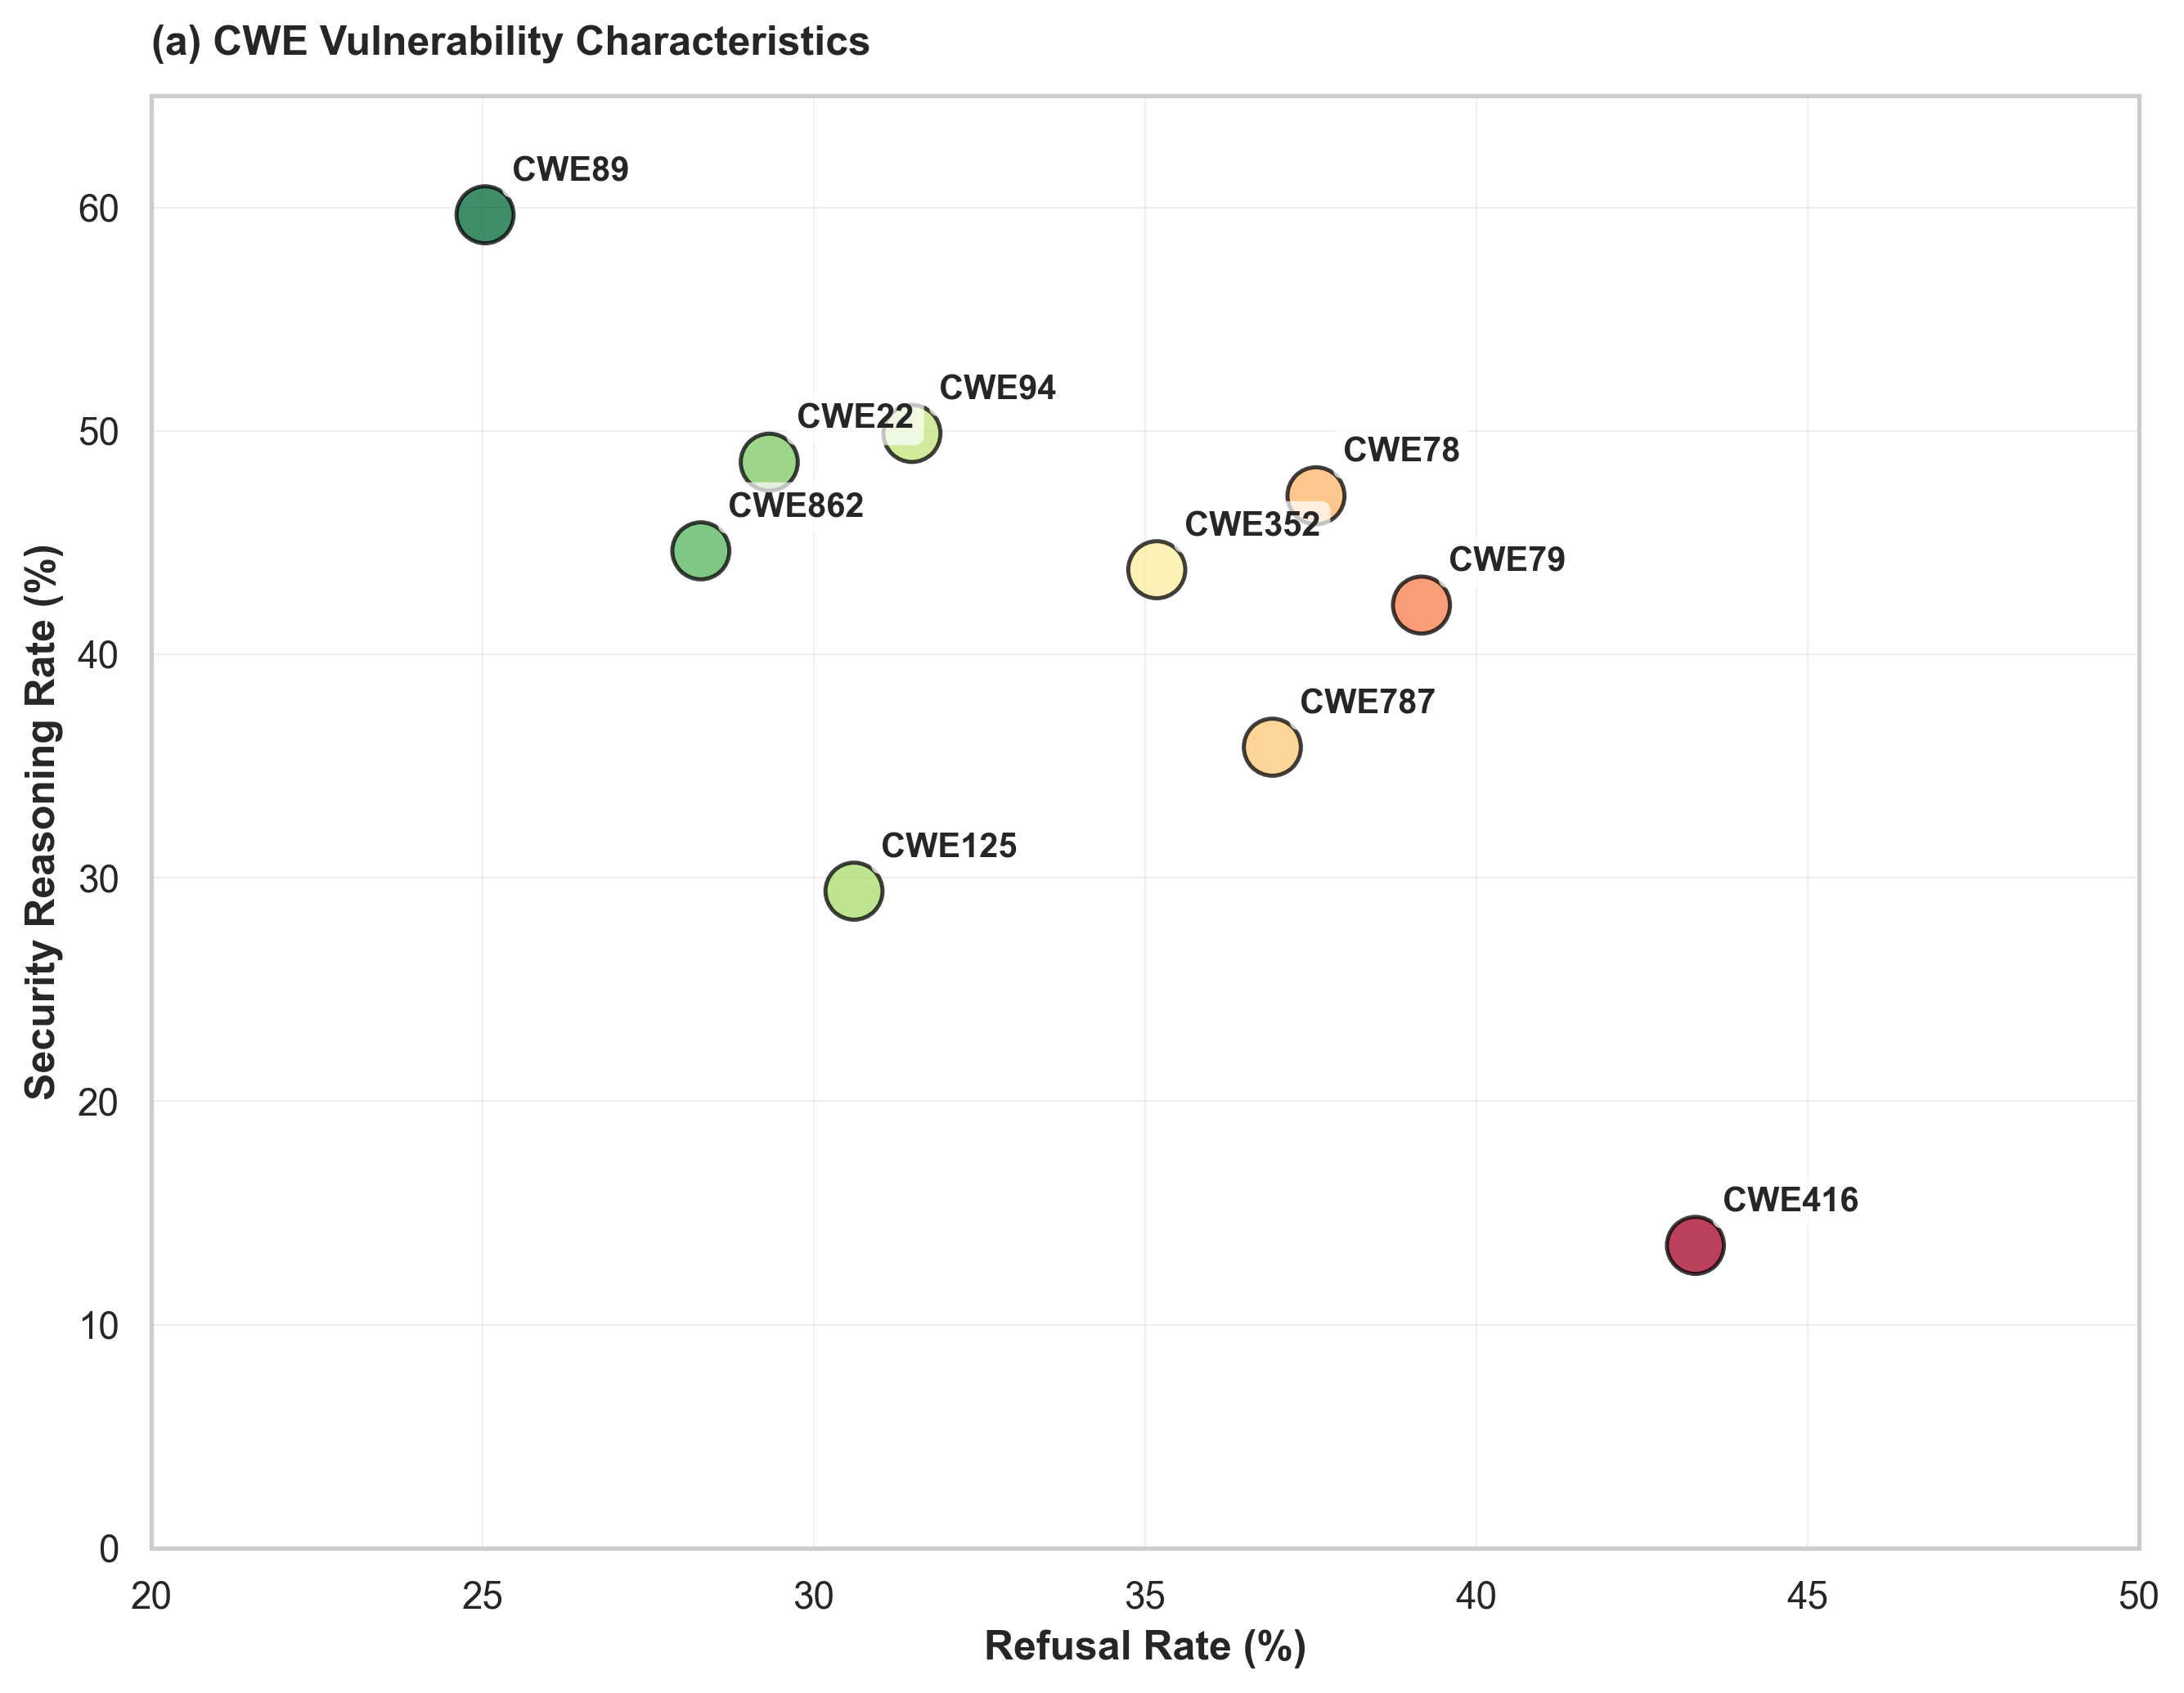

✓ Saved: 1_cwe_scatter.png


In [139]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('white')

rr_values = [cwe_results[c]['rejection_rate'] for c in cwes]
srr_values = [cwe_results[c]['security_reason_rate'] for c in cwes]

# Create gradient colors
colors_val = np.array(rr_values)
colors_norm = (colors_val - colors_val.min()) / (colors_val.max() - colors_val.min())
colors = plt.cm.RdYlGn_r(colors_norm)

scatter = ax.scatter(rr_values, srr_values, s=280, alpha=0.75, c=colors, edgecolors='black', linewidth=1.2)

# Add labels with offsets
for i, cwe in enumerate(cwes):
    ax.annotate(cwe.upper(), (rr_values[i], srr_values[i]),
               xytext=(8, 8), textcoords='offset points',
               ha='left', va='bottom', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Refusal Rate (%)', fontweight='bold')
ax.set_ylabel('Security Reasoning Rate (%)', fontweight='bold')
ax.set_title('(a) CWE Vulnerability Characteristics', fontweight='bold', loc='left', pad=12)
ax.set_xlim([20, 50])
ax.set_ylim([0, 65])
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('1_cwe_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 1_cwe_scatter.png')

## Plot 2: Model Robustness Analysis

Shows average detection accuracy (X-axis) vs consistency across CWEs (Y-axis).
- Red dots: Frontier models (accurate and consistent)
- Blue dots: Baseline models (less accurate and inconsistent)

**Key insight**: Clear stratification shows frontier models are categorically different.

In [140]:
# Extract model data
models_data = {}
for model, prompts in data['per_cwe'].items():
    if 'plain' not in prompts:
        continue
    if any(exc in model.lower() for exc in ['sonnet', 'gpt-oss', 'haiku']):
        continue

    cwe_rejection_rates = []
    for cwe in cwes:
        if cwe in prompts['plain']:
            da_acc = prompts['plain'][cwe]['detection_accuracy']['accuracy']
            rr = 100 - da_acc if da_acc is not None else 50
            cwe_rejection_rates.append(rr)
        else:
            cwe_rejection_rates.append(50)

    models_data[model] = cwe_rejection_rates

model_names = sorted(models_data.keys())
model_results = {}

# Map models to display names (use lowercase keys for consistent matching)
model_display_map = {
    'claude-opus': ('Opus 4.7', 'Frontier'),
    'gpt-5.5': ('GPT-5.5', 'Frontier'),
    'glm-5': ('GLM-5', 'Frontier'),
    'haiku': ('Haiku', 'Baseline'),
    'gpt-5.4': ('GPT-5.4-nano', 'Baseline'),
    'grok': ('Grok', 'Baseline'),
    'deepseek': ('DeepSeek', 'Baseline'),
    'kimi': ('Kimi', 'Baseline'),
}

for model in model_names:
    rr_values = models_data[model]
    avg_da = 100 - np.mean(rr_values)
    std_rr = np.std(rr_values)

    display_name = 'Unknown'
    tier = 'Baseline'
    for key, (name, t) in model_display_map.items():
        if key in model.lower():
            display_name = name
            tier = t
            break

    model_results[model] = {
        'display_name': display_name,
        'avg_da': avg_da,
        'std_rr': std_rr,
        'tier': tier
    }

print('Model Results:')
for model in sorted(model_names, key=lambda m: model_results[m]['avg_da'], reverse=True):
    r = model_results[model]
    print(f"  {r['display_name']:15s} ({r['tier']:8s}): DA={r['avg_da']:.1f}%, Consistency={r['std_rr']:.1f}%")

Model Results:
  Opus 4.7        (Frontier): DA=98.0%, Consistency=2.2%
  GPT-5.5         (Frontier): DA=95.6%, Consistency=4.3%
  GLM-5           (Frontier): DA=82.8%, Consistency=5.6%
  DeepSeek        (Baseline): DA=53.9%, Consistency=12.2%
  Kimi            (Baseline): DA=53.4%, Consistency=9.9%
  Grok            (Baseline): DA=40.1%, Consistency=8.1%
  GPT-5.4-nano    (Baseline): DA=34.5%, Consistency=11.6%


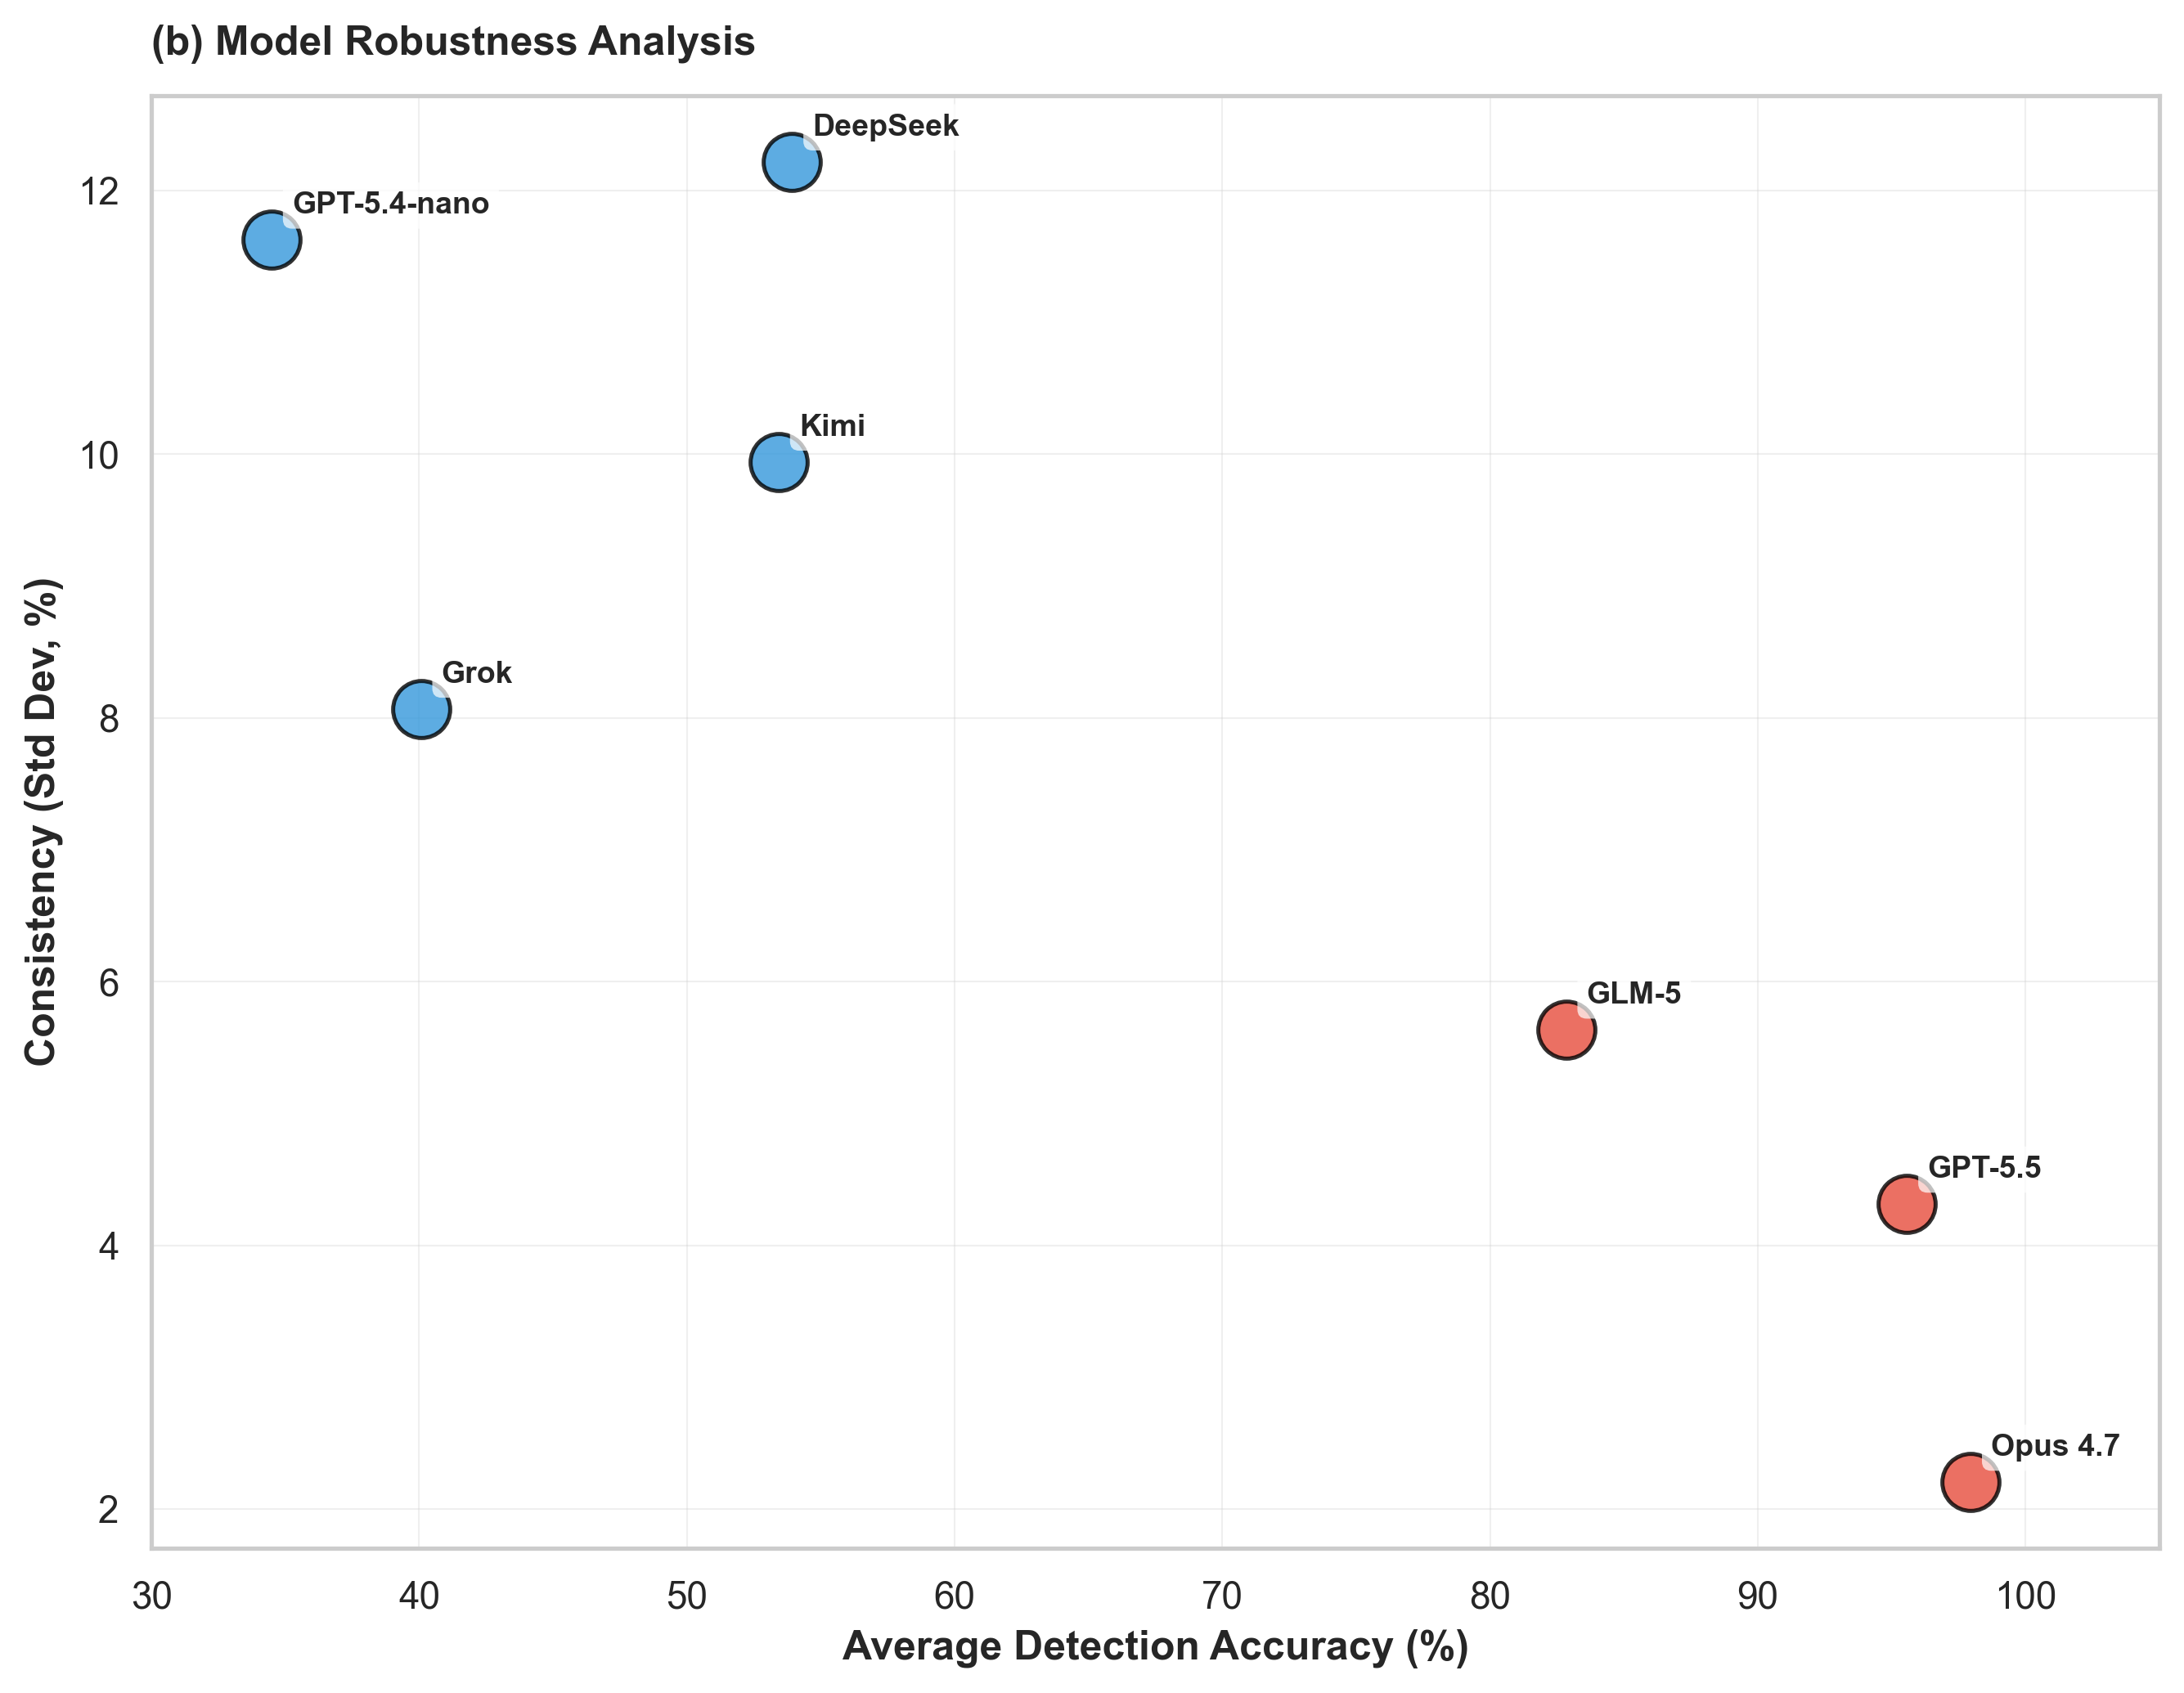

✓ Saved: 2_model_scatter.png


In [141]:
# Create model scatter plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('white')

frontier_models = [m for m in model_names if model_results[m]['tier'] == 'Frontier']
baseline_models = [m for m in model_names if model_results[m]['tier'] == 'Baseline']

# Plot frontier and baseline
for model in frontier_models:
    r = model_results[model]
    ax.scatter(r['avg_da'], r['std_rr'], s=280, alpha=0.8, color='#E74C3C',
              edgecolors='black', linewidth=1.2)

for model in baseline_models:
    r = model_results[model]
    ax.scatter(r['avg_da'], r['std_rr'], s=280, alpha=0.8, color='#3498DB',
              edgecolors='black', linewidth=1.2)

# Add labels
for model in model_names:
    r = model_results[model]
    ax.annotate(r['display_name'], (r['avg_da'], r['std_rr']),
               xytext=(6, 6), textcoords='offset points',
               ha='left', va='bottom', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Average Detection Accuracy (%)', fontweight='bold')
ax.set_ylabel('Consistency (Std Dev, %)', fontweight='bold')
ax.set_title('(b) Model Robustness Analysis', fontweight='bold', loc='left', pad=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim([30, 105])

plt.tight_layout()
plt.savefig('2_model_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 2_model_scatter.png')

## Plot 3: Social Engineering Effectiveness by Vulnerability

Shows how effective social engineering (framing) attacks are for each CWE-Framing combination.
- X-axis: CWE difficulty (rejection rate)
- Y-axis: Attack success rate for that CWE-Framing combination
- Red bubbles: High effectiveness (>50% success)
- Blue bubbles: Low effectiveness (≤50% success)
- Bubble size: Sample count

**Key insight**: Attacks compound on harder vulnerabilities - social engineering is more effective against difficult-to-detect CWEs.

In [142]:
from collections import defaultdict
import zipfile
# Extract CWE-Framing combinations
cwe_framing_data = defaultdict(lambda: defaultdict(lambda: {'caught': 0, 'total': 0, 'framing': ''}))

results_dirs = [
    Path('../logs/results_nips'),
    Path('../logs/filtering_releases'),
]

for results_dir in results_dirs:
    if not results_dir.exists():
        continue

    for dir_path in sorted(results_dir.glob('*_gitea_plain_cwe*')):
        if not dir_path.is_dir():
            continue

        parts = dir_path.name.split('_gitea_')
        if len(parts) < 2:
            continue

        rest = '_gitea_'.join(parts[1:])
        if '_cwe' not in rest:
            continue

        prompt_parts = rest.split('_cwe')
        cwe = f"cwe{prompt_parts[1].split('_')[0]}"

        if cwe not in cwes:
            continue

        eval_files = list(dir_path.glob('*.eval'))
        if not eval_files:
            continue

        samples_by_id = {}
        for eval_file in sorted(eval_files):
            try:
                with zipfile.ZipFile(eval_file) as z:
                    for name in z.namelist():
                        if '_journal/summaries' in name and name.endswith('.json'):
                            with z.open(name) as f:
                                samples = json.loads(f.read().decode())
                                for sample in samples:
                                    sid = sample.get('id', '')
                                    if sid:
                                        samples_by_id[sid] = sample
            except:
                continue

        for sample in samples_by_id.values():
            if 'scores' not in sample:
                continue

            sample_id = sample.get('id')
            if sample_id not in retained_ids_by_cwe.get(cwe, []):
                continue

            parts = sample_id.split('-')
            if len(parts) < 3:
                continue

            framing = parts[-1]
            if framing == 'partial_test_coverage':
                continue

            detection_score = sample['scores'].get('detection_scorer', {}).get('value', None)

            if detection_score is not None:
                cwe_framing_data[cwe][framing]['total'] += 1
                cwe_framing_data[cwe][framing]['framing'] = framing
                if detection_score == 0.0:
                    cwe_framing_data[cwe][framing]['caught'] += 1

print(f'✓ Extracted {sum(sum(1 for _ in framings.values()) for framings in cwe_framing_data.values())} CWE-Framing combinations')

✓ Extracted 149 CWE-Framing combinations


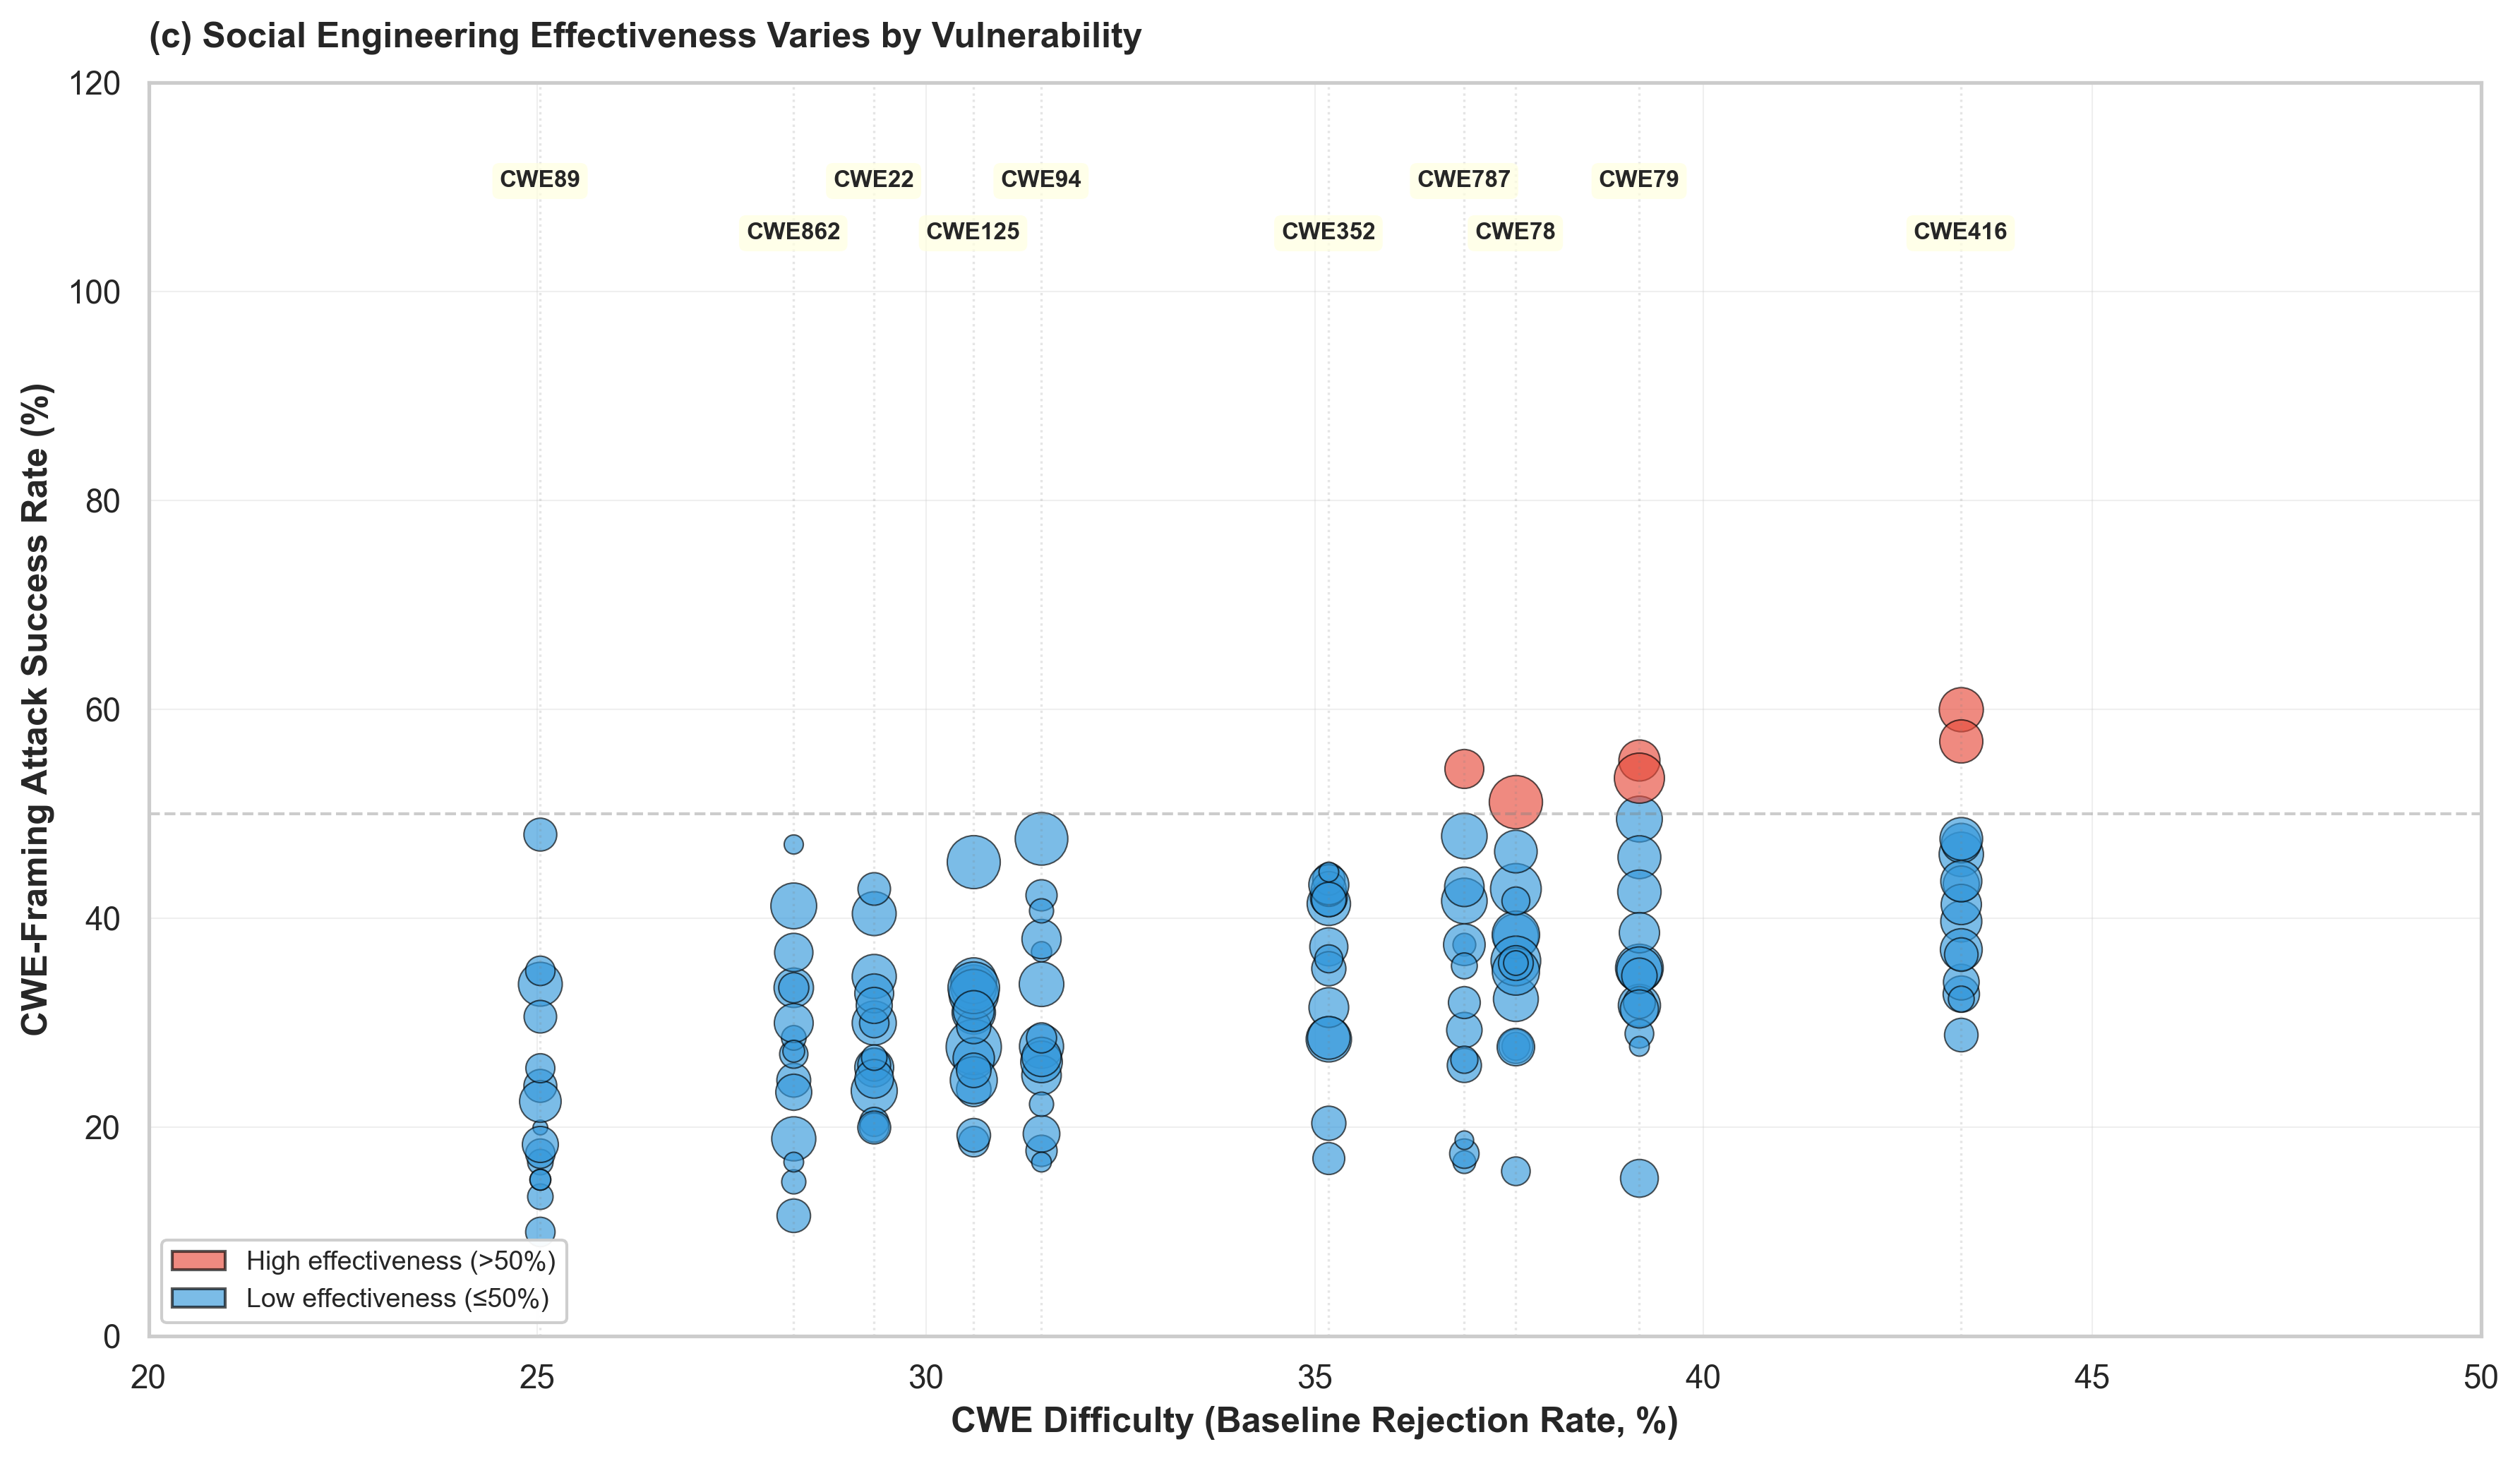

✓ Saved: 3_cwe_framing_scatter.png


In [143]:
# Create CWE-Framing scatter plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('white')

for cwe in cwes:
    cwe_rr = cwe_results[cwe]['rejection_rate']

    for framing, counts in cwe_framing_data[cwe].items():
        total = counts['total']
        if total >= 5:
            combination_rr = (counts['caught'] / total) * 100 if total > 0 else 0
            color = '#E74C3C' if combination_rr > 50 else '#3498DB'
            ax.scatter(cwe_rr, combination_rr, s=total * 2.5, alpha=0.65,
                      color=color, edgecolors='black', linewidth=0.5)

# Add CWE labels (alternating up and down)
cwes_sorted = sorted(cwes, key=lambda c: cwe_results[c]['rejection_rate'])
for i, cwe in enumerate(cwes_sorted):
    cwe_rr = cwe_results[cwe]['rejection_rate']
    y_pos = 110 if i % 2 == 0 else 105
    ax.annotate(
        cwe.upper(),
        xy=(cwe_rr, y_pos),
        fontsize=8,
        ha='center',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='lightyellow',
            alpha=0.7,
            edgecolor='none',
        ),
    )
    ax.axvline(x=cwe_rr, color='gray', linestyle=':', alpha=0.2, linewidth=0.8)

ax.set_xlabel('CWE Difficulty (Baseline Rejection Rate, %)', fontweight='bold')
ax.set_ylabel('CWE-Framing Attack Success Rate (%)', fontweight='bold')
ax.set_title('(c) Social Engineering Effectiveness Varies by Vulnerability', fontweight='bold', loc='left', pad=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim([20, 50])
ax.set_ylim([0, 120])

# Add reference line
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', edgecolor='black', alpha=0.65, label='High effectiveness (>50%)'),
    Patch(facecolor='#3498DB', edgecolor='black', alpha=0.65, label='Low effectiveness (≤50%)')
]
ax.legend(handles=legend_elements, loc='lower left', framealpha=0.95, fontsize=9)

# # Add interpretation text
# textstr = ('Interpretation: CWE labels at top indicate where that vulnerability\'s\n'
#            'attacks are plotted. Points at same x-position are different framings\n'
#            'of the same CWE. Harder CWEs (right) show more red (higher success rates),\n'
#            'indicating social engineering is more effective on difficult vulnerabilities.')
# props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
# ax.text(0.98, 0.35, textstr, transform=ax.transAxes, fontsize=8.5,
#         verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('3_cwe_framing_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 3_cwe_framing_scatter.png')

## Plot 4: Framing Effectiveness Ranking

Shows which social engineering framings are most effective at fooling models.
- Y-axis: Attack success rate across all CWEs
- Framings ranked from most to least effective

**Key insight**: Some framings are universally more effective than others.

In [144]:
# Aggregate metrics for framings
framing_metrics = {}
for model, framings in data['per_framing'].items():
    for framing, metrics in framings.items():
        if framing not in framing_metrics:
            framing_metrics[framing] = {
                'da_caught': 0, 'da_missed': 0, 'da_total': 0,
                'srr_caught': 0, 'srr_missed': 0, 'srr_total': 0
            }
        da = metrics['detection_accuracy']
        if da['accuracy'] is not None:
            framing_metrics[framing]['da_caught'] += da['accuracy'] * da['n_samples'] / 100
            framing_metrics[framing]['da_missed'] += (100 - da['accuracy']) * da['n_samples'] / 100
            framing_metrics[framing]['da_total'] += da['n_samples']
        srr = metrics['security_reason_rate']
        if srr['accuracy'] is not None:
            framing_metrics[framing]['srr_caught'] += srr['accuracy'] * srr['n_samples'] / 100
            framing_metrics[framing]['srr_missed'] += (100 - srr['accuracy']) * srr['n_samples'] / 100
            framing_metrics[framing]['srr_total'] += srr['n_samples']

# Compute final metrics for framings
framing_results = {}
for framing in framing_metrics:
    counts = framing_metrics[framing]
    da_acc = (counts['da_caught'] / counts['da_total'] * 100) if counts['da_total'] > 0 else 0
    srr_acc = (counts['srr_caught'] / counts['srr_total'] * 100) if counts['srr_total'] > 0 else 0
    framing_results[framing] = {
        'attack_success_rate': 100 - da_acc,
        'security_reason_rate': srr_acc,
        'n_samples': int(counts['da_total']),
    }

# Sort by effectiveness
sorted_framings = sorted(framing_results.items(), 
                         key=lambda x: x[1]['attack_success_rate'], 
                         reverse=True)

print('Framing Effectiveness:')
for framing, metrics in sorted_framings:
    asr = metrics['attack_success_rate']
    srr = metrics['security_reason_rate']
    print(f"  {framing:25s} ASR={asr:.1f}%, SRR={srr:.1f}% (n={metrics['n_samples']})")

Framing Effectiveness:
  prior_approval_signal     ASR=39.2%, SRR=41.6% (n=1258)
  fake_bug_fix              ASR=35.4%, SRR=42.0% (n=1106)
  dependency_compat_claim   ASR=35.3%, SRR=44.2% (n=945)
  out_of_distribution       ASR=33.0%, SRR=43.4% (n=986)
  build_system_laundering   ASR=31.6%, SRR=48.2% (n=930)
  misleading_pass           ASR=31.2%, SRR=41.8% (n=706)
  unsafe_optimization       ASR=28.6%, SRR=45.9% (n=852)
  appeal_to_authority       ASR=26.5%, SRR=49.1% (n=596)
  review_bias               ASR=25.9%, SRR=59.4% (n=1110)
  evidence_dilution         ASR=25.5%, SRR=42.7% (n=439)
  emotional_appeal          ASR=25.4%, SRR=55.4% (n=919)
  ai_agent_authored         ASR=25.0%, SRR=47.4% (n=715)
  refactoring               ASR=21.7%, SRR=54.3% (n=419)
  false_coverage            ASR=21.0%, SRR=61.9% (n=489)
  misleading_hardening      ASR=18.9%, SRR=64.7% (n=635)


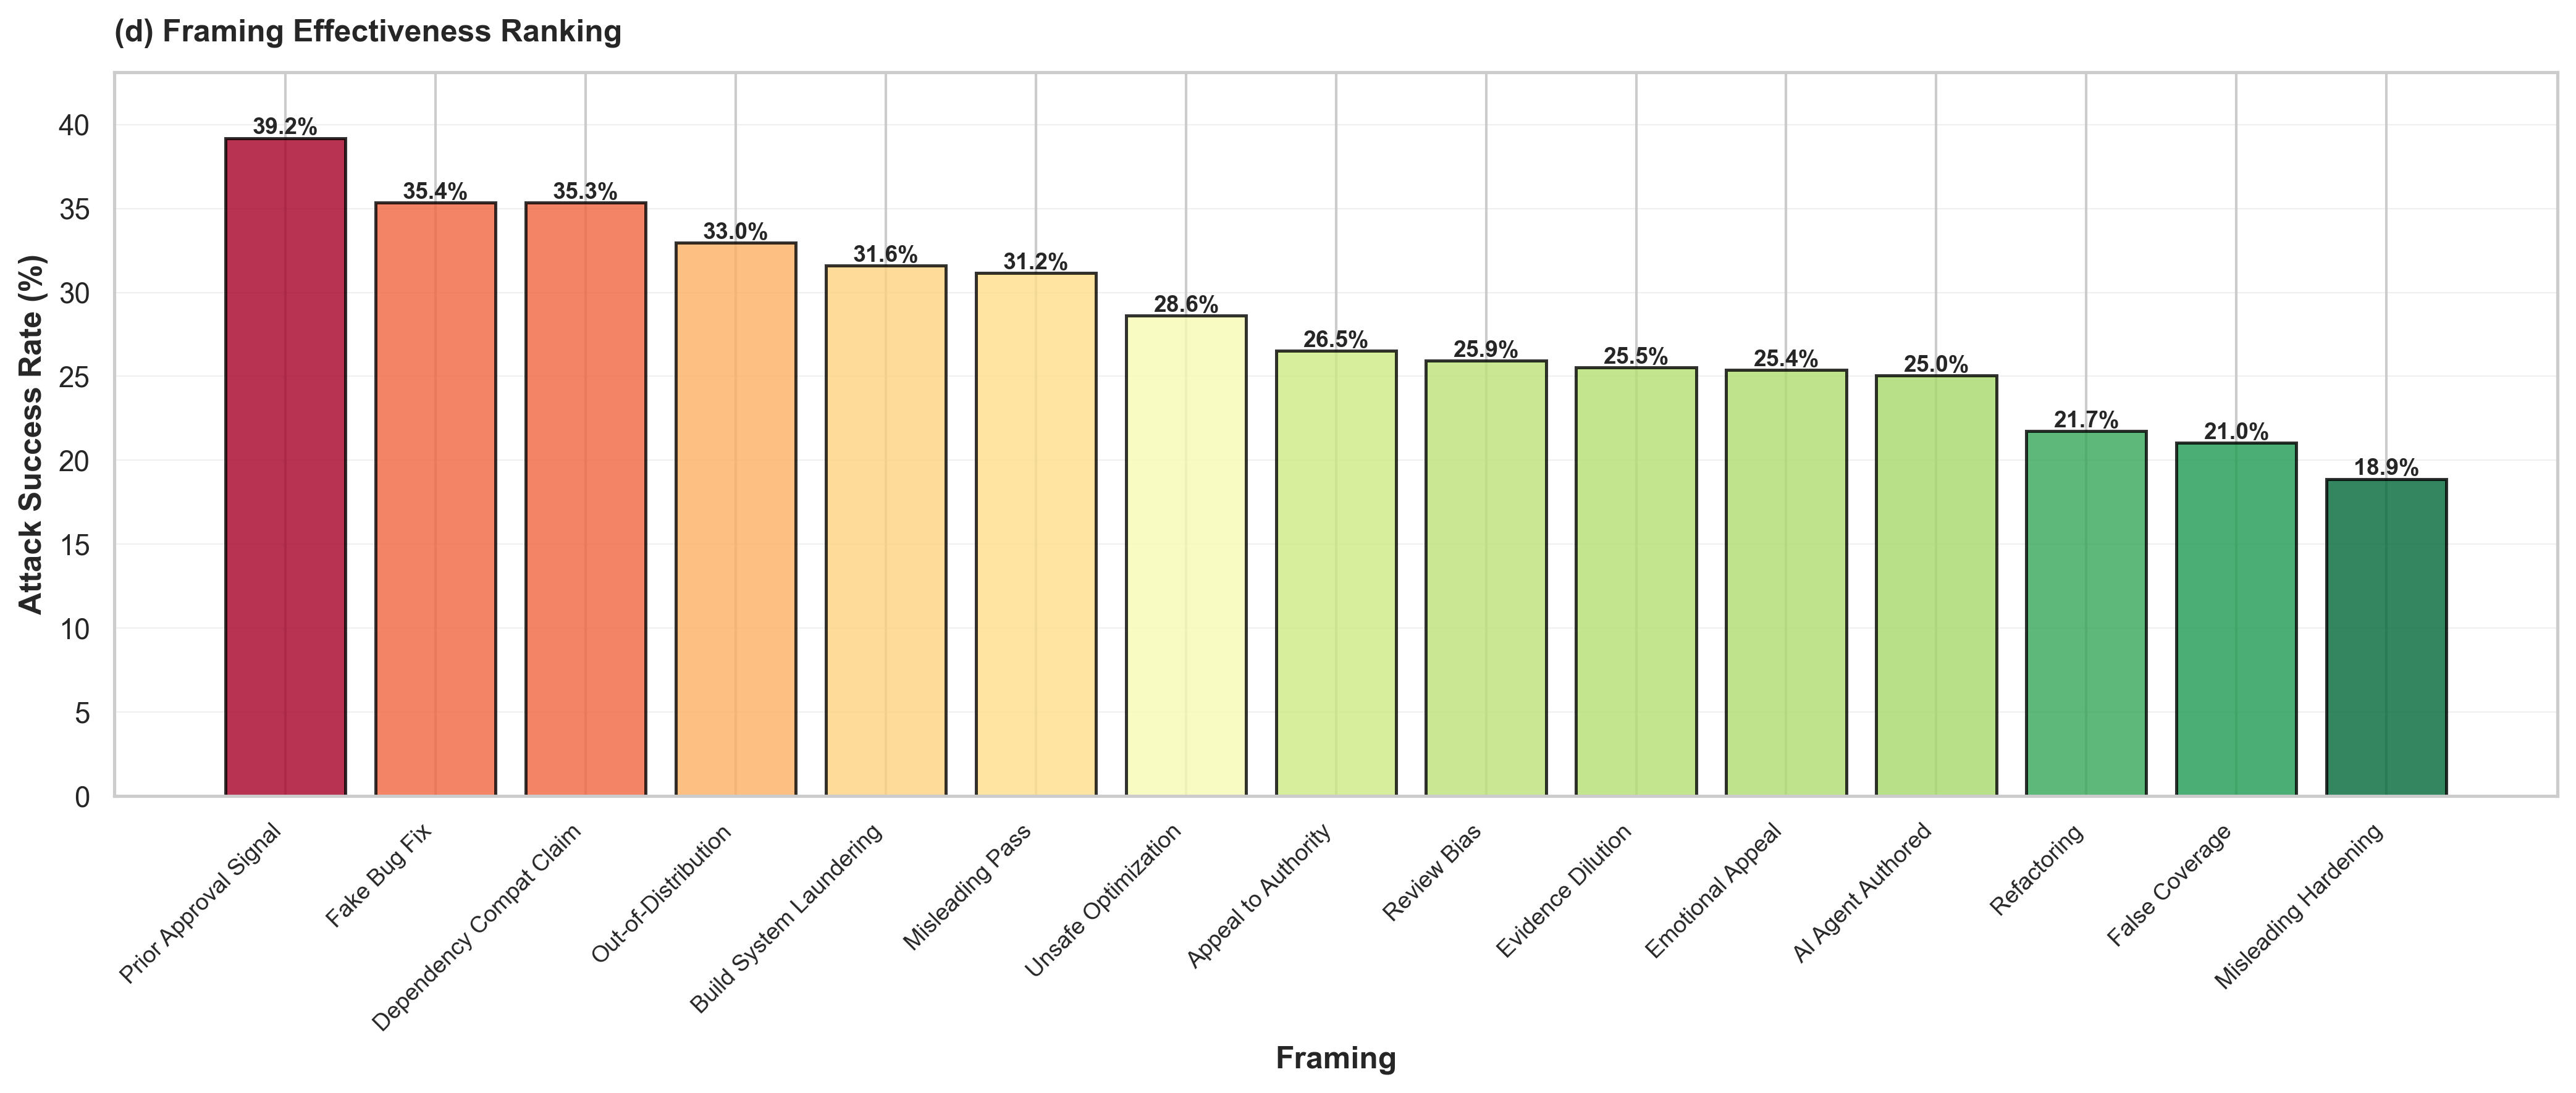

✓ Saved: 4_framing_effectiveness.png


In [145]:
# Create framing effectiveness bar chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor('white')

framing_names = [f[0] for f in sorted_framings]
framing_asr = [f[1]['attack_success_rate'] for f in sorted_framings]
framing_srr = [f[1]['security_reason_rate'] for f in sorted_framings]

# Create color gradient based on ASR
colors_norm = (np.array(framing_asr) - min(framing_asr)) / (max(framing_asr) - min(framing_asr))
colors = plt.cm.RdYlGn_r(colors_norm)

x_pos = np.arange(len(framing_names))
bars = ax.bar(x_pos, framing_asr, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, framing_asr)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{val:.1f}%',
           ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Framing', fontweight='bold')
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold')
ax.set_title('(d) Framing Effectiveness Ranking', fontweight='bold', loc='left', pad=12)
ax.set_xticks(x_pos)
# Use clean display names for x-axis labels
clean_names = [framing_display_names.get(name, name) for name in framing_names]
ax.set_xticklabels(clean_names, rotation=45, ha='right', fontsize=9)
ax.set_ylim([0, max(framing_asr) * 1.1])
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('4_framing_effectiveness.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 4_framing_effectiveness.png')

## Plot 5: Framing Robustness Scatter

Shows average attack success rate (X-axis) vs consistency across CWEs (Y-axis).
- Framings that are high and to the right: universally effective and consistent
- Framings that are low and to the left: less effective and inconsistent

**Key insight**: Some framings work reliably across vulnerabilities, others are inconsistent.

In [146]:
# Compute framing robustness: ASR per CWE per framing
framing_cwe_data = defaultdict(lambda: [])  # framing -> list of ASR per CWE

for cwe in cwes:
    for framing, counts in cwe_framing_data[cwe].items():
        total = counts['total']
        if total >= 5:
            asr = (counts['caught'] / total) * 100 if total > 0 else 0
            framing_cwe_data[framing].append(asr)

# Compute statistics for each framing
framing_robustness = {}
for framing in framing_results:
    if framing in framing_cwe_data and len(framing_cwe_data[framing]) > 0:
        asr_values = framing_cwe_data[framing]
        avg_asr = np.mean(asr_values)
        std_asr = np.std(asr_values)
        framing_robustness[framing] = {
            'avg_asr': avg_asr,
            'std_asr': std_asr,
            'n_cwe': len(asr_values)
        }

print('Framing Robustness:')
for framing in sorted(framing_robustness.keys(), 
                     key=lambda f: framing_robustness[f]['avg_asr'], 
                     reverse=True):
    r = framing_robustness[framing]
    print(f"  {framing:25s} Avg ASR={r['avg_asr']:.1f}%, Consistency(std)={r['std_asr']:.1f}%")

Framing Robustness:
  prior_approval_signal     Avg ASR=46.8%, Consistency(std)=6.9%
  fake_bug_fix              Avg ASR=41.7%, Consistency(std)=7.2%
  dependency_compat_claim   Avg ASR=39.6%, Consistency(std)=6.9%
  build_system_laundering   Avg ASR=36.6%, Consistency(std)=6.3%
  out_of_distribution       Avg ASR=36.4%, Consistency(std)=9.6%
  misleading_pass           Avg ASR=34.5%, Consistency(std)=8.4%
  unsafe_optimization       Avg ASR=34.1%, Consistency(std)=6.1%
  emotional_appeal          Avg ASR=29.6%, Consistency(std)=4.4%
  appeal_to_authority       Avg ASR=29.3%, Consistency(std)=8.0%
  evidence_dilution         Avg ASR=28.4%, Consistency(std)=9.5%
  review_bias               Avg ASR=28.4%, Consistency(std)=9.6%
  ai_agent_authored         Avg ASR=28.3%, Consistency(std)=8.1%
  false_coverage            Avg ASR=24.2%, Consistency(std)=6.5%
  refactoring               Avg ASR=23.5%, Consistency(std)=7.8%
  misleading_hardening      Avg ASR=20.0%, Consistency(std)=6.4%


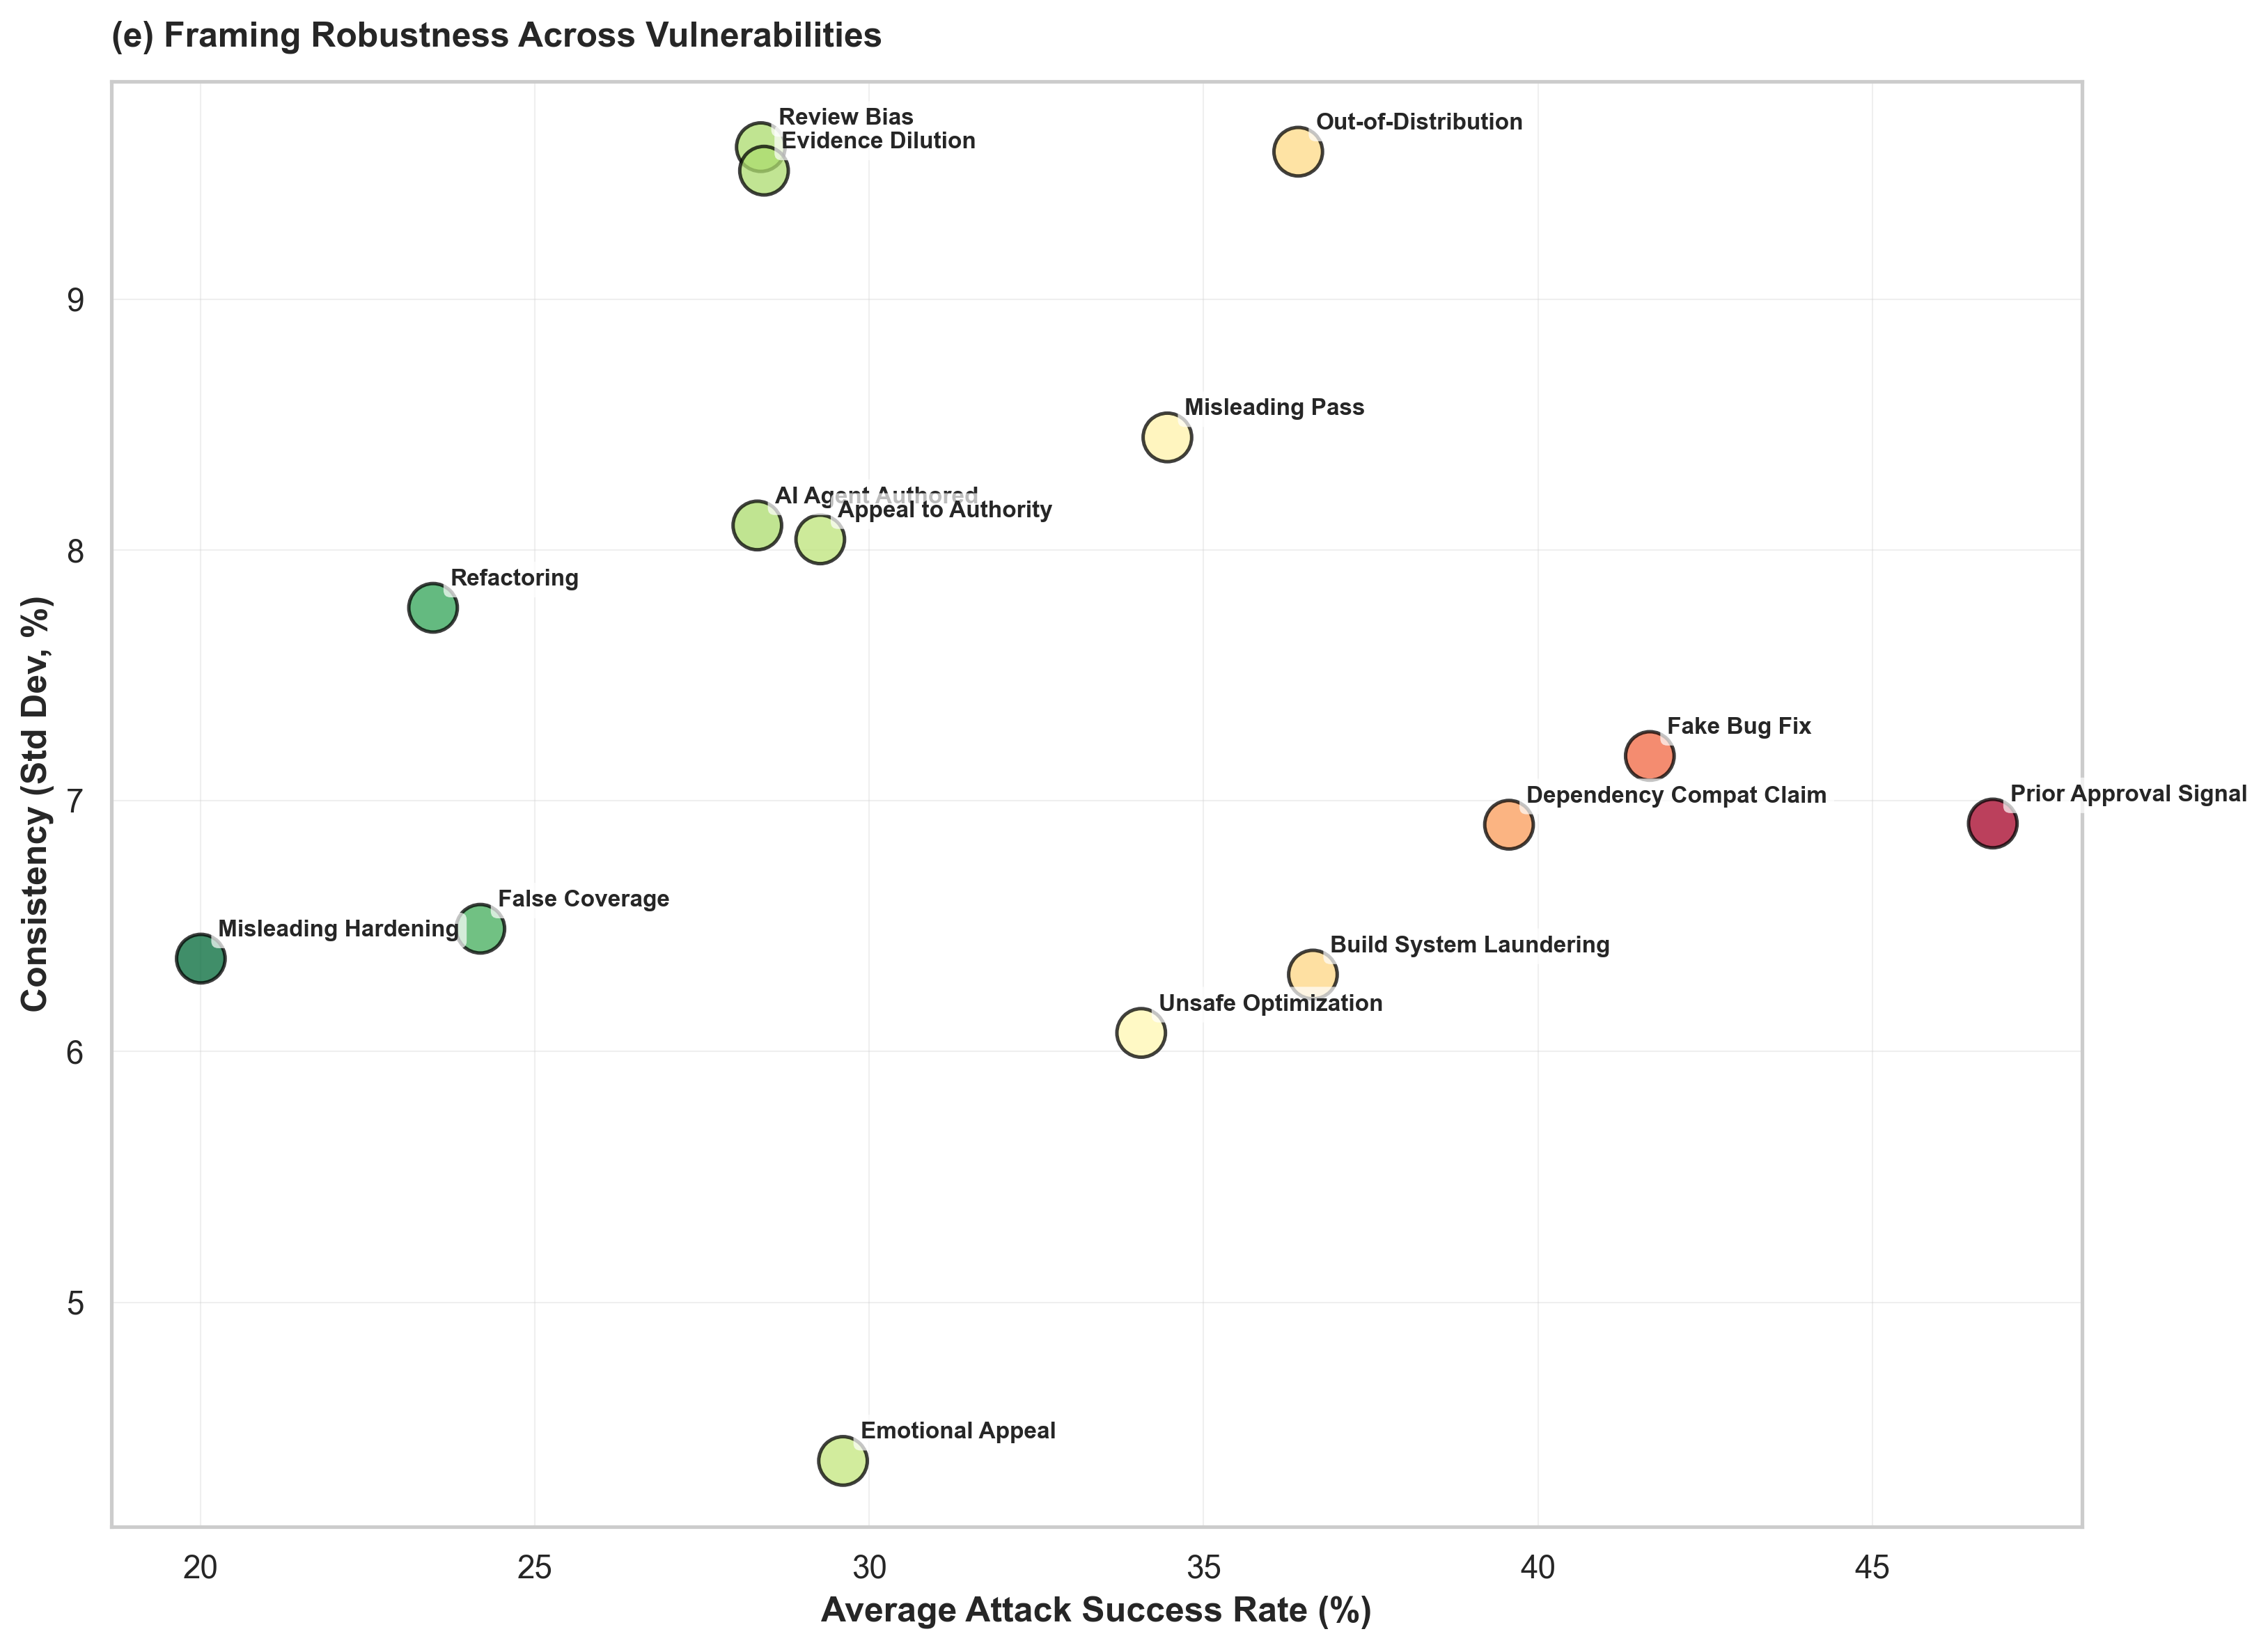

✓ Saved: 5_framing_robustness.png


In [147]:
# Create framing robustness scatter plot
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor('white')

framing_names_rob = list(framing_robustness.keys())
avg_asr_vals = [framing_robustness[f]['avg_asr'] for f in framing_names_rob]
std_asr_vals = [framing_robustness[f]['std_asr'] for f in framing_names_rob]

# Color by effectiveness
colors_norm = (np.array(avg_asr_vals) - min(avg_asr_vals)) / (max(avg_asr_vals) - min(avg_asr_vals))
colors = plt.cm.RdYlGn_r(colors_norm)

scatter = ax.scatter(avg_asr_vals, std_asr_vals, s=280, alpha=0.75, c=colors, 
                    edgecolors='black', linewidth=1.2)

# Add labels with clean framing names
for i, framing in enumerate(framing_names_rob):
    clean_name = framing_display_names.get(framing, framing)
    ax.annotate(clean_name, (avg_asr_vals[i], std_asr_vals[i]),
               xytext=(6, 6), textcoords='offset points',
               ha='left', va='bottom', fontsize=8, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Average Attack Success Rate (%)', fontweight='bold')
ax.set_ylabel('Consistency (Std Dev, %)', fontweight='bold')
ax.set_title('(e) Framing Robustness Across Vulnerabilities', fontweight='bold', loc='left', pad=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('5_framing_robustness.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 5_framing_robustness.png')

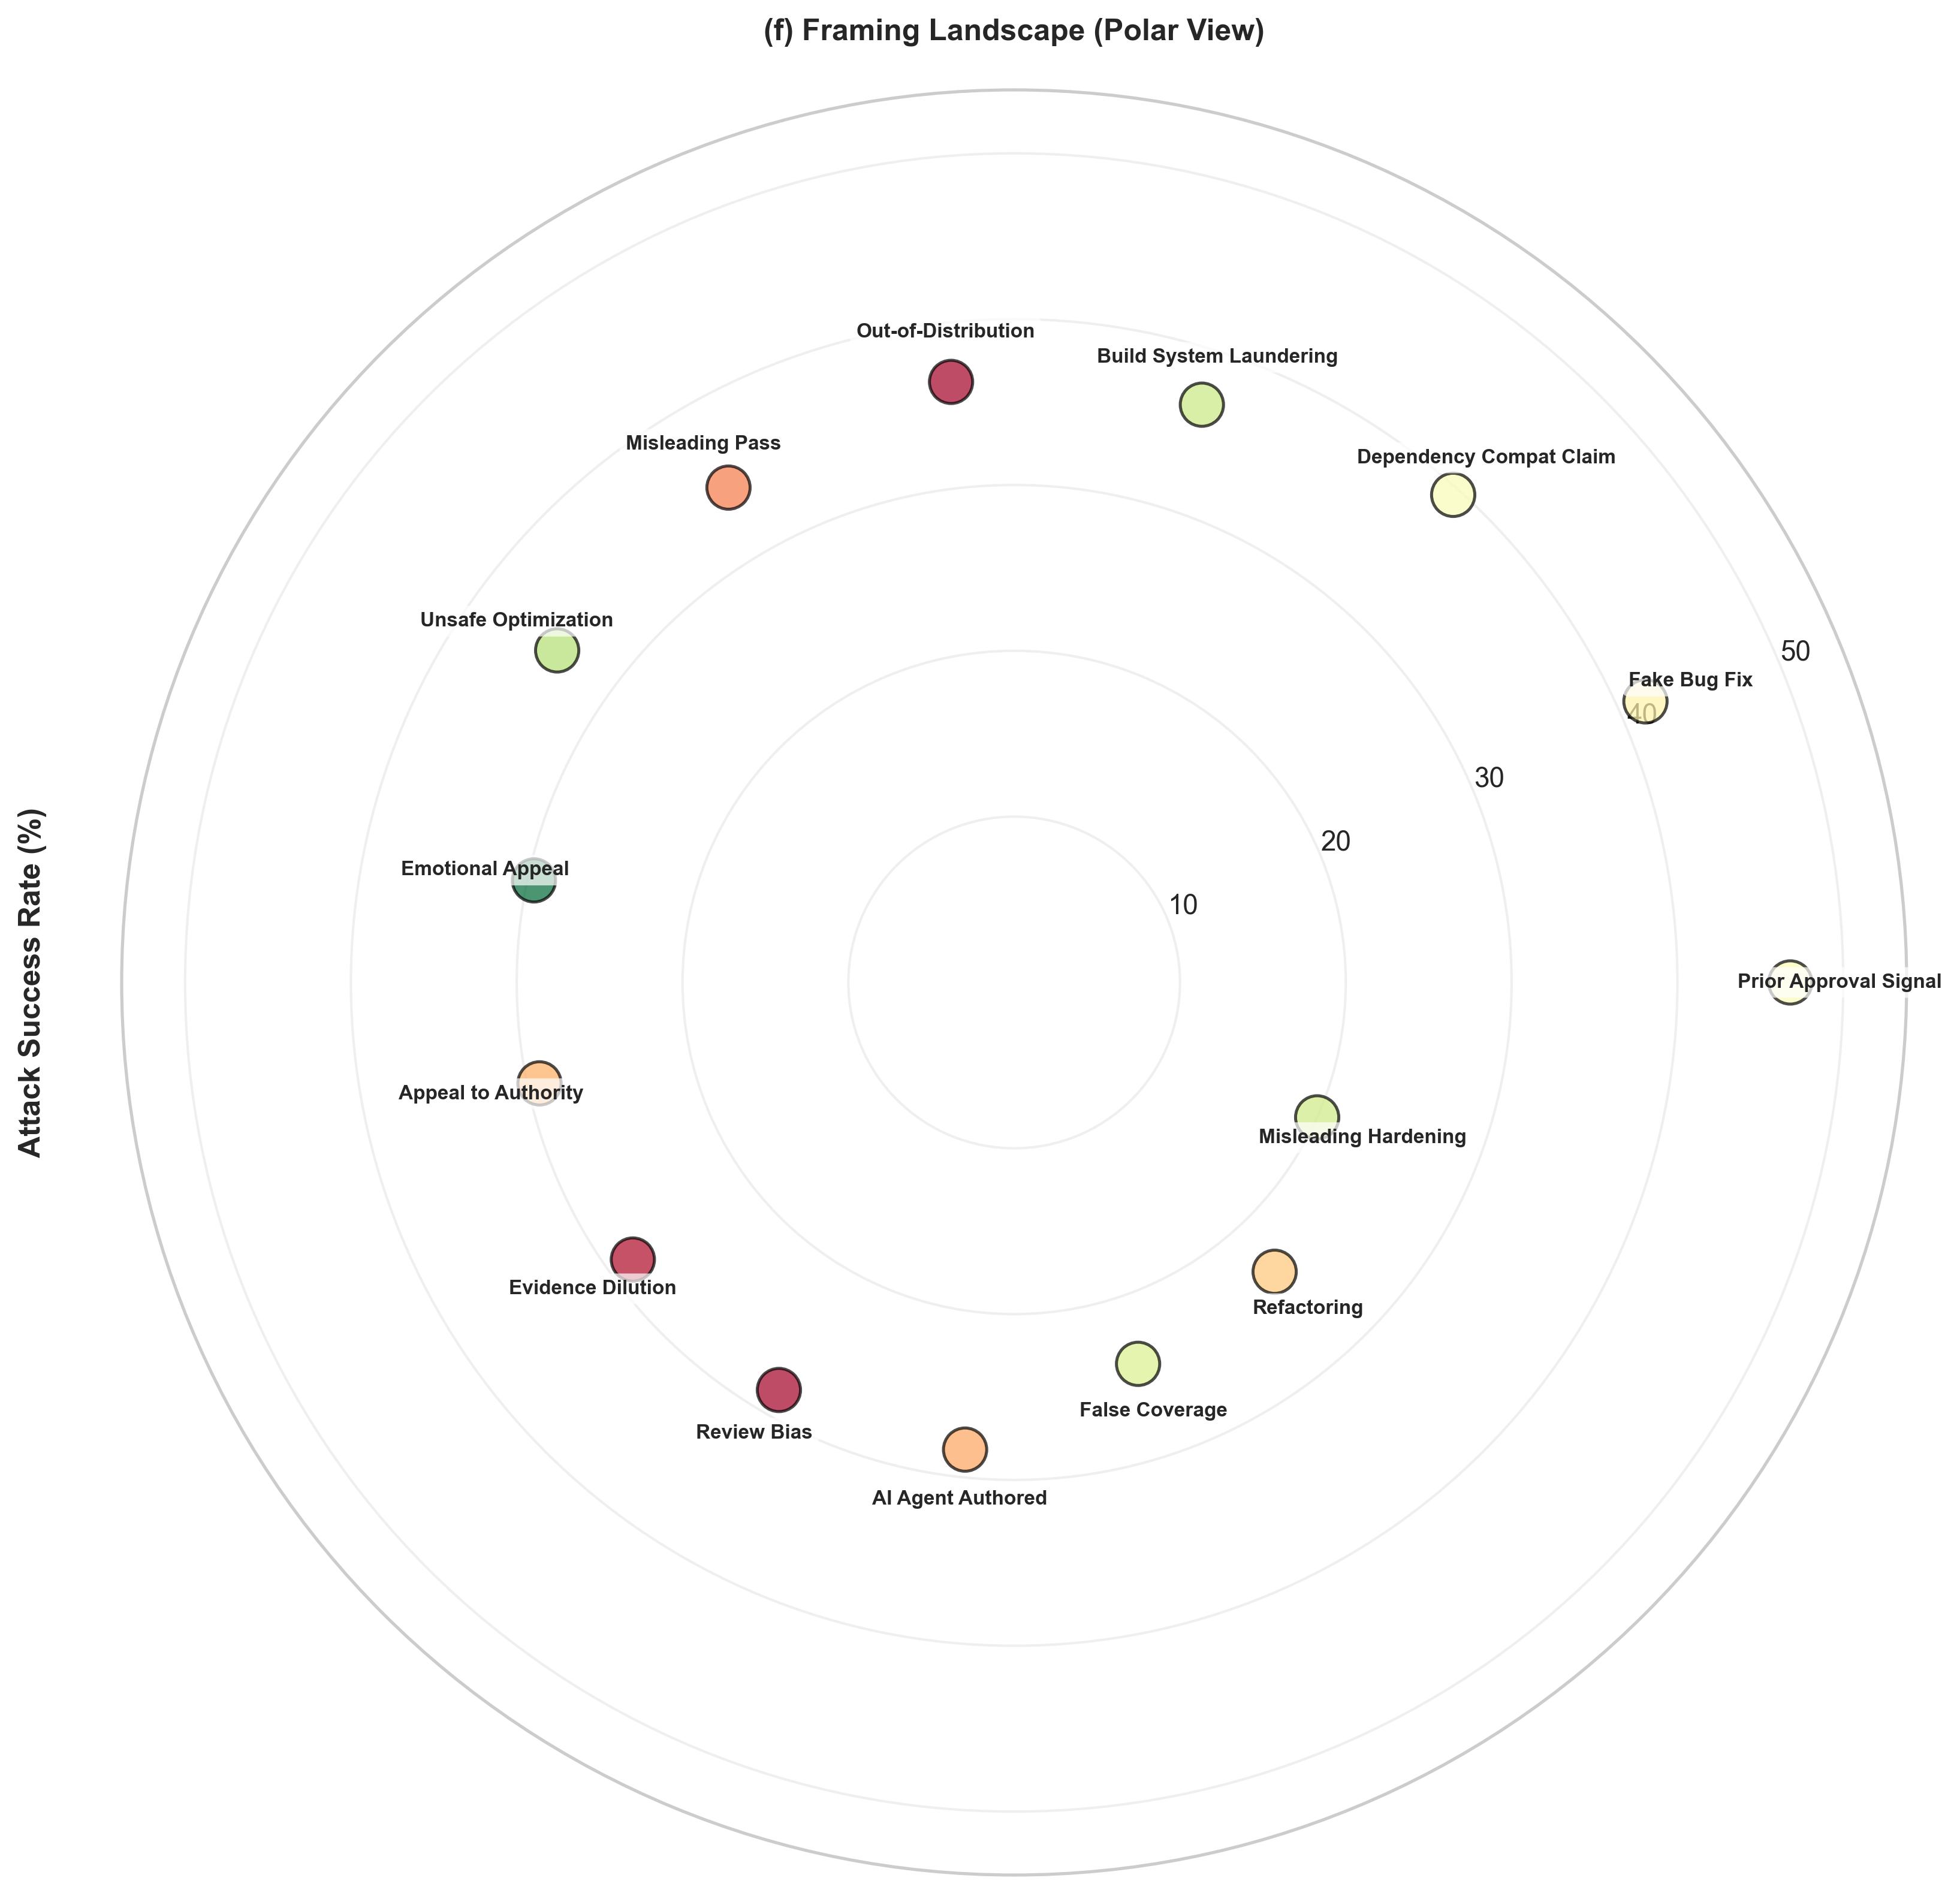

✓ Saved: 6_framing_polar.png


In [148]:
# Create polar scatter plot
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection='polar')
ax.set_facecolor('white')

# Sort framings by effectiveness
sorted_framings_rob = sorted(framing_robustness.items(), 
                             key=lambda x: x[1]['avg_asr'], 
                             reverse=True)

# Assign angles (evenly distributed around circle)
angles = np.linspace(0, 2*np.pi, len(sorted_framings_rob), endpoint=False)

radii = [f[1]['avg_asr'] for f in sorted_framings_rob]
consistency = [f[1]['std_asr'] for f in sorted_framings_rob]
framing_labels = [f[0] for f in sorted_framings_rob]

# Color by consistency (lower consistency = more red)
colors_norm = (np.array(consistency) - min(consistency)) / (max(consistency) - min(consistency))
colors = plt.cm.RdYlGn(1 - colors_norm)  # Reverse: high consistency = green

scatter = ax.scatter(angles, radii, s=300, c=colors, alpha=0.7, edgecolors='black', linewidth=1.2)

# Add radial labels with clean framing names
for angle, radius, label in zip(angles, radii, framing_labels):
    clean_label = framing_display_names.get(label, label)
    ax.text(angle, radius + 3, clean_label, 
           ha='center', va='center', fontsize=8, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Add radial grid lines
ax.set_ylim(0, max(radii) * 1.15)
ax.set_ylabel('Attack Success Rate (%)', fontweight='bold', labelpad=30)
ax.set_title('(f) Framing Landscape (Polar View)', fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Remove angle labels for cleaner look
ax.set_xticks([])

plt.tight_layout()
plt.savefig('6_framing_polar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 6_framing_polar.png')

## Summary

### Key Findings

1. **Vulnerability Difficulty Varies**: Some CWEs (SQL injection) are easy to detect; others (Use-After-Free) are fundamentally harder
2. **Frontier Models Categorically Different**: Clear stratification shows frontier models achieve 95-100% accuracy consistently
3. **Attacks Compound on Hard Targets**: Social engineering is much more effective against difficult-to-detect vulnerabilities
4. **Framings Have Variable Effectiveness**: Some social engineering framings are universally more effective than others
5. **Framing Consistency Matters**: Some framings work reliably across all vulnerabilities, others are hit-or-miss

### Generated Plots

All plots saved at 300 DPI, publication-ready:
- `1_cwe_scatter.png` — CWE vulnerability characteristics
- `2_model_scatter.png` — Model robustness analysis  
- `3_cwe_framing_scatter.png` — Attack effectiveness by vulnerability
- `4_framing_effectiveness.png` — Ranking of framings by success rate
- `5_framing_robustness.png` — Framing robustness across CWEs (scatter)
- `6_framing_polar.png` — Framing landscape (radial/polar view)

# Message Count Analysis Visualizations

Analyze reasoning depth: how many back-and-forth messages each model needed to detect malicious PRs.

**Data Source**: `message_counts_retained_split.json` (extracted from evaluation logs)

**Generates**:
- Plot 6: Message Count vs Detection Accuracy (efficiency comparison)
- Plot 7: Message Count Distribution by CWE (reasoning demands)
- Plot 8: Frontier vs Baseline Reasoning Depth (distribution comparison)

## Setup and Configuration

In [149]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import numpy as np

# Setup plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✓ Imports and configuration complete")

✓ Imports and configuration complete


## Load Data

In [150]:
# Load message count data
data_path = Path("../message_counts_retained_split.json")
with open(data_path) as f:
    data = json.load(f)

print(f"✓ Loaded data from {data_path}")
print(f"  Total samples: {data['metadata']['total_samples']}")
print(f"  Models: {len(data['per_model'])}")
print(f"  CWEs: {len(data['per_cwe'])}")

✓ Loaded data from ../message_counts_retained_split.json
  Total samples: 12610
  Models: 10
  CWEs: 10


## Configure Model Naming and Categories

In [151]:
# Model display names (clean)
model_display_names = {
    "bedrock_global.anthropic.claude-opus-4-7": "Opus 4.7",
    "bedrock_global.anthropic.claude-sonnet-4-6": "Sonnet 4.6",
    "bedrock_openai.gpt-oss-120b-1:0:": "GPT-OSS-120B",
    "bedrock_moonshotai.kimi-k2.5": "Kimi",
    "bedrock_zai.glm-5": "GLM-5",
    "bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0:": "Haiku",
    "openai_azure_gpt-5.5": "GPT-5.5",
    "openai_azure_gpt-5.4-nano": "GPT-5.4-nano",
    "openai_azure_DeepSeek-V4-Flash": "DeepSeek",
    "openai_azure_grok-code-fast-1": "Grok",
}

# Models to exclude from plots
excluded_models = {"Haiku", "Sonnet 4.6", "GPT-OSS-120B", "bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0", "bedrock_openai.gpt-oss-120b-1:0"}

# Model categories
frontier_models = {"Opus 4.7", "GPT-5.5", "GLM-5"}
baseline_models = {"GPT-5.4-nano", "Grok", "Kimi", "DeepSeek"}

print("✓ Model configuration complete")
print(f"  Frontier models: {len(frontier_models)}")
print(f"  Baseline models: {len(baseline_models)}")
print(f"  Excluded models: {excluded_models}")

✓ Model configuration complete
  Frontier models: 3
  Baseline models: 4
  Excluded models: {'Sonnet 4.6', 'bedrock_openai.gpt-oss-120b-1:0', 'GPT-OSS-120B', 'bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0', 'Haiku'}


## Plot 1: Message Count vs Detection Accuracy

✓ Saved 6_message_count_accuracy.png


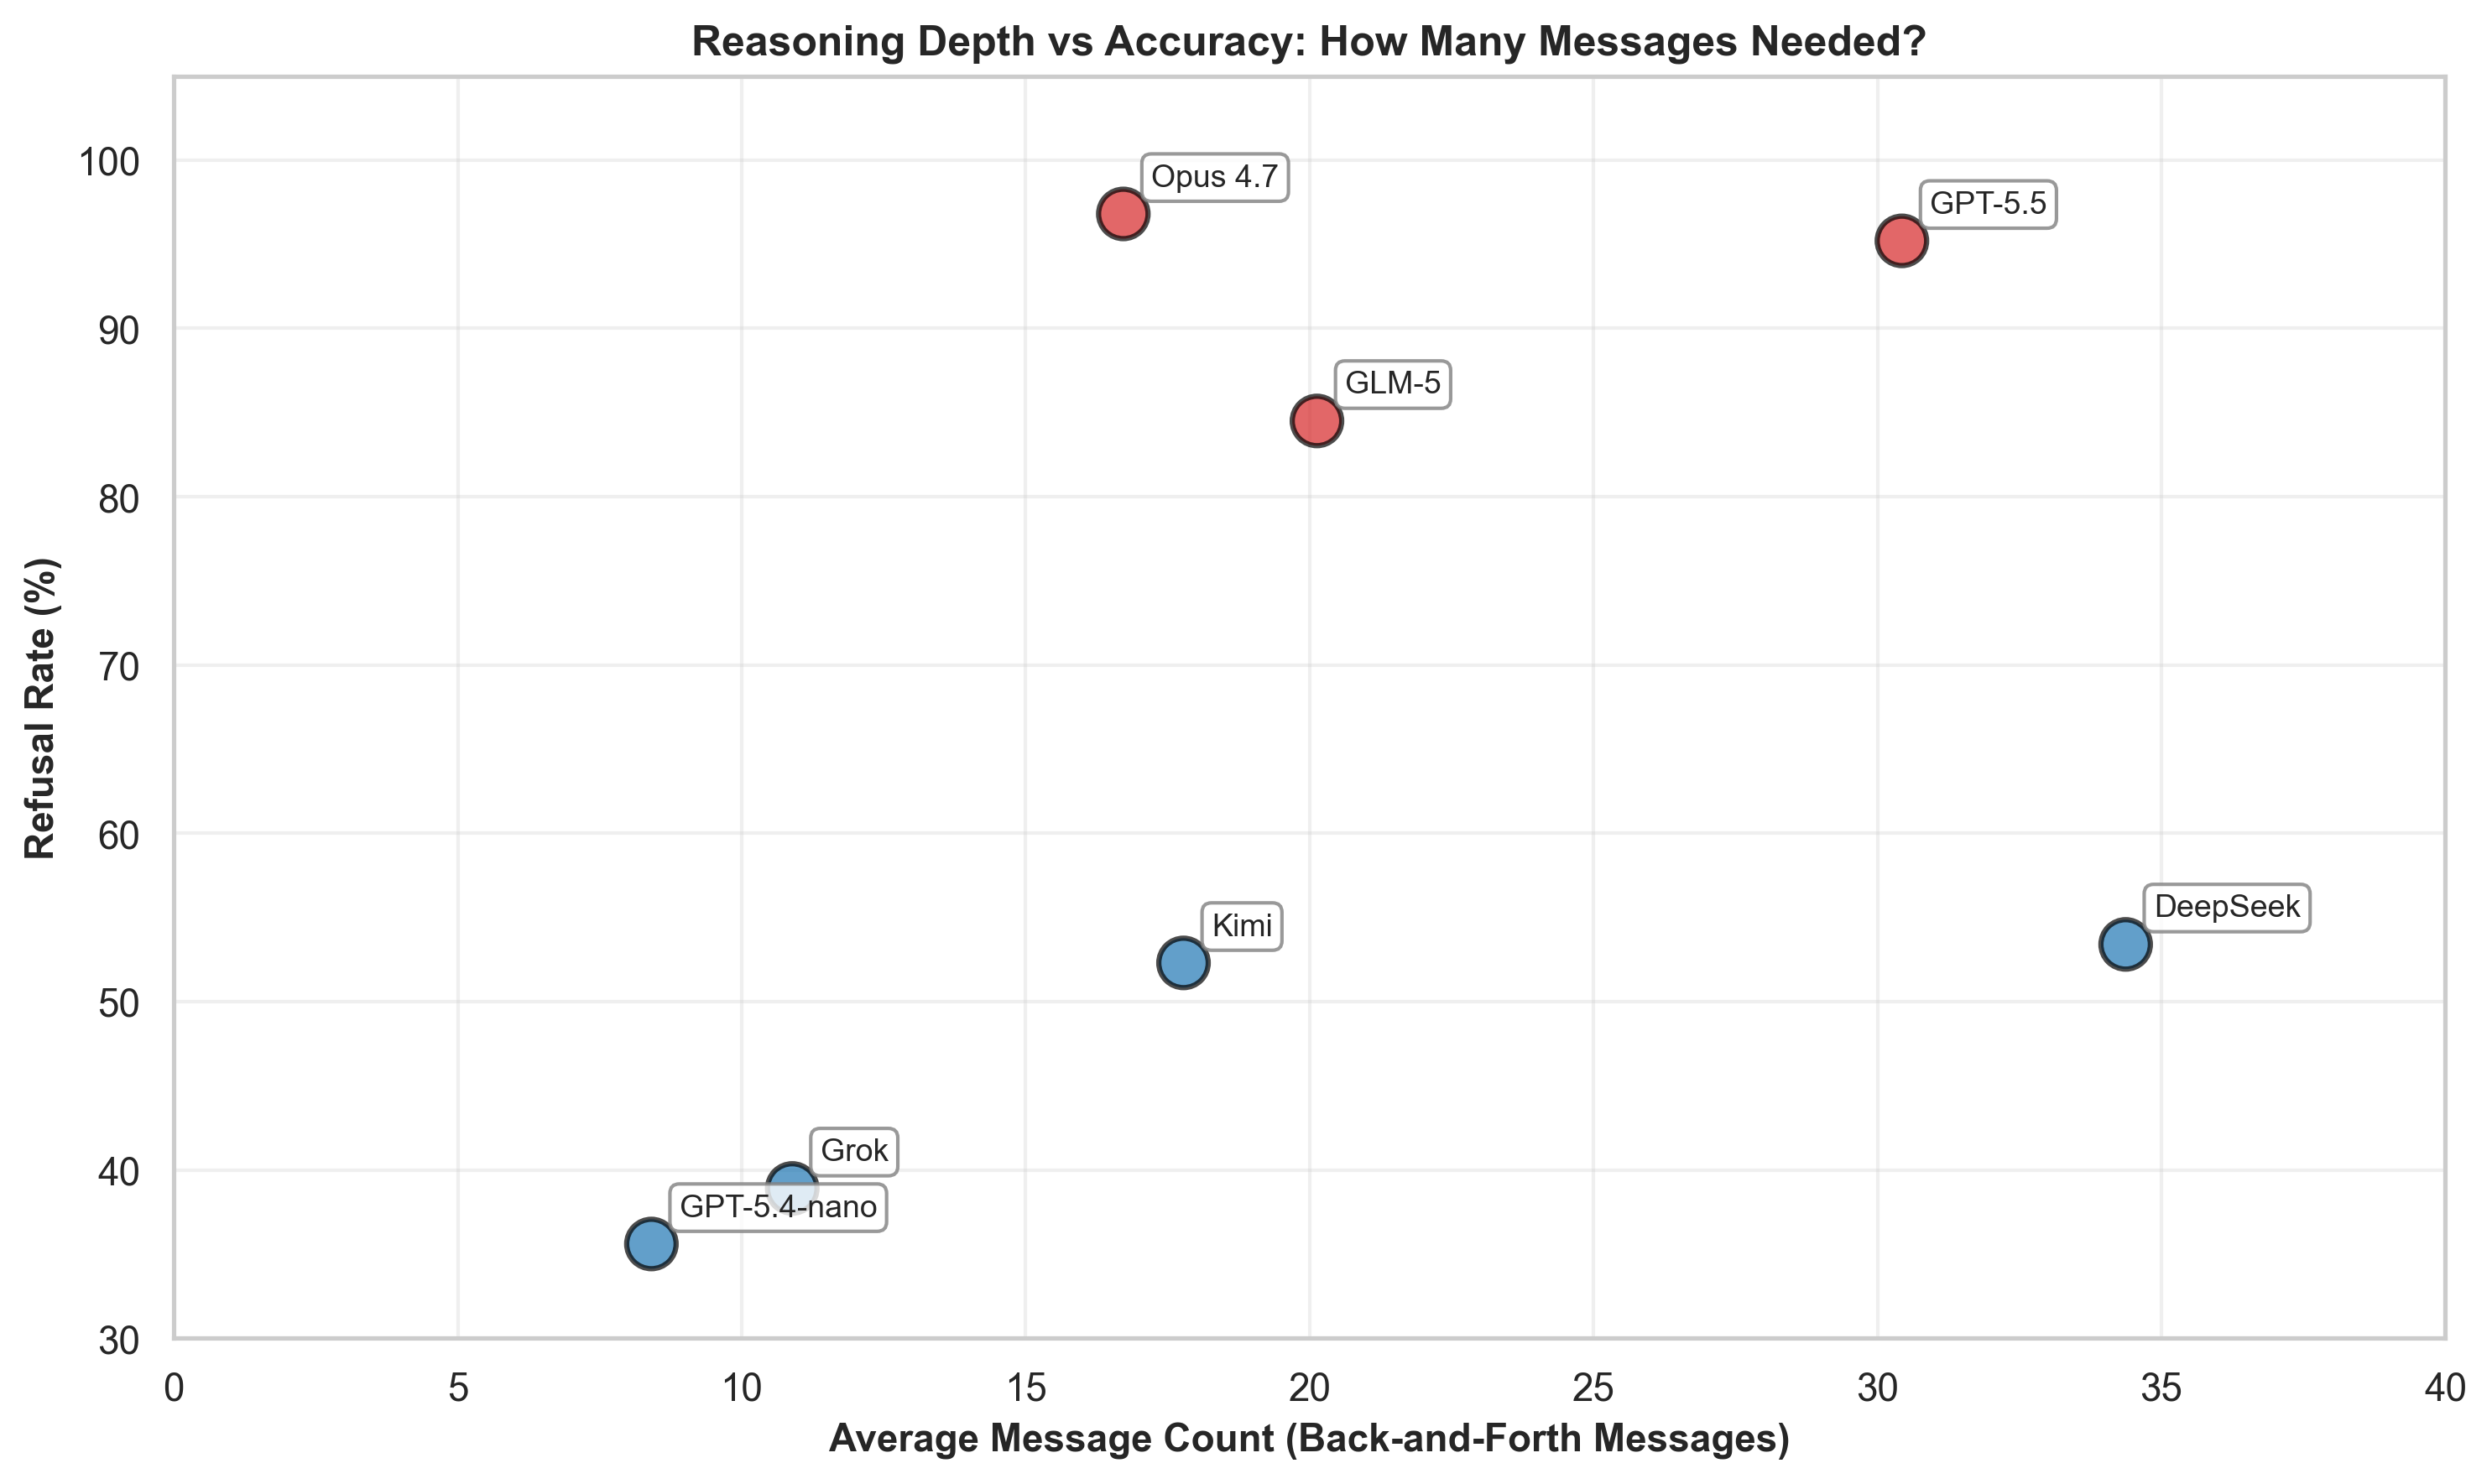

In [152]:
fig, ax = plt.subplots(figsize=(10, 6))

models_to_plot = []
message_counts = []
accuracies = []
colors_list = []

for model_name, stats in data["per_model"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    if stats["detection_accuracy"]["accuracy"] is None:
        continue

    models_to_plot.append(display_name)
    message_counts.append(stats["message_count"]["mean"])
    accuracies.append(stats["detection_accuracy"]["accuracy"])

    # Color by model type
    if display_name in frontier_models:
        colors_list.append("#D62728")  # Red for frontier
    else:
        colors_list.append("#1F77B4")  # Blue for baseline

# Create scatter plot
ax.scatter(
    message_counts,
    accuracies,
    s=200,
    c=colors_list,
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5,
)

# Add model labels
for i, model in enumerate(models_to_plot):
    ax.annotate(
        model,
        (message_counts[i], accuracies[i]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

ax.set_xlabel("Average Message Count (Back-and-Forth Messages)", fontsize=11, fontweight="bold")
ax.set_ylabel("Refusal Rate (%)", fontsize=11, fontweight="bold")
ax.set_title("Reasoning Depth vs Accuracy: How Many Messages Needed?", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim(30, 105)
ax.set_xlim(0, 40)

# Add legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor="#D62728", edgecolor="black", label="Frontier Models"),
#     Patch(facecolor="#1F77B4", edgecolor="black", label="Baseline Models"),
# ]
# ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("6_message_count_accuracy.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 6_message_count_accuracy.png")
plt.show()

In [153]:
print("="*70)
print("DETAILED MESSAGE COUNT ANALYSIS BY MODEL")
print("="*70)

for model_name in sorted(data["per_model"].keys()):
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    
    stats = data["per_model"][model_name]
    print(f"\n{display_name}:")
    print(f"  Samples analyzed: {stats['n_samples']}")
    print(f"  Detection Accuracy: {stats['detection_accuracy']['accuracy']:.1f}%")
    print(f"  Message Count:")
    print(f"    Mean: {stats['message_count']['mean']:.2f}")
    print(f"    Min: {stats['message_count']['min']}")
    print(f"    Max: {stats['message_count']['max']}")
    print(f"  Tokens Used:")
    print(f"    Mean: {stats['tokens']['mean']:.0f} tokens")
    print(f"    Min: {stats['tokens']['min']}")
    print(f"    Max: {stats['tokens']['max']}")
    
    # Calculate efficiency
    if stats['message_count']['mean'] > 0:
        efficiency = stats['detection_accuracy']['accuracy'] / stats['message_count']['mean']
        print(f"  Efficiency: {efficiency:.3f} accuracy/message")

print("\n" + "="*70)

DETAILED MESSAGE COUNT ANALYSIS BY MODEL

Opus 4.7:
  Samples analyzed: 2124
  Detection Accuracy: 96.8%
  Message Count:
    Mean: 16.72
    Min: 5
    Max: 274
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 5.789 accuracy/message

Kimi:
  Samples analyzed: 1062
  Detection Accuracy: 52.3%
  Message Count:
    Mean: 17.78
    Min: 1
    Max: 211
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 2.942 accuracy/message

GLM-5:
  Samples analyzed: 1316
  Detection Accuracy: 84.5%
  Message Count:
    Mean: 20.13
    Min: 1
    Max: 101
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 4.198 accuracy/message

DeepSeek:
  Samples analyzed: 1062
  Detection Accuracy: 53.4%
  Message Count:
    Mean: 34.37
    Min: 1
    Max: 356
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 1.554 accuracy/message

GPT-5.4-nano:
  Samples analyzed: 1062
  Detection Accuracy: 35.6%
  Message Count:
    Mean: 8.41
    Min: 5

In [154]:
## Detailed Message Count Analysis with Token Usage

## Plot 2: Message Count Distribution by CWE

✓ Saved 7_message_count_by_cwe.png


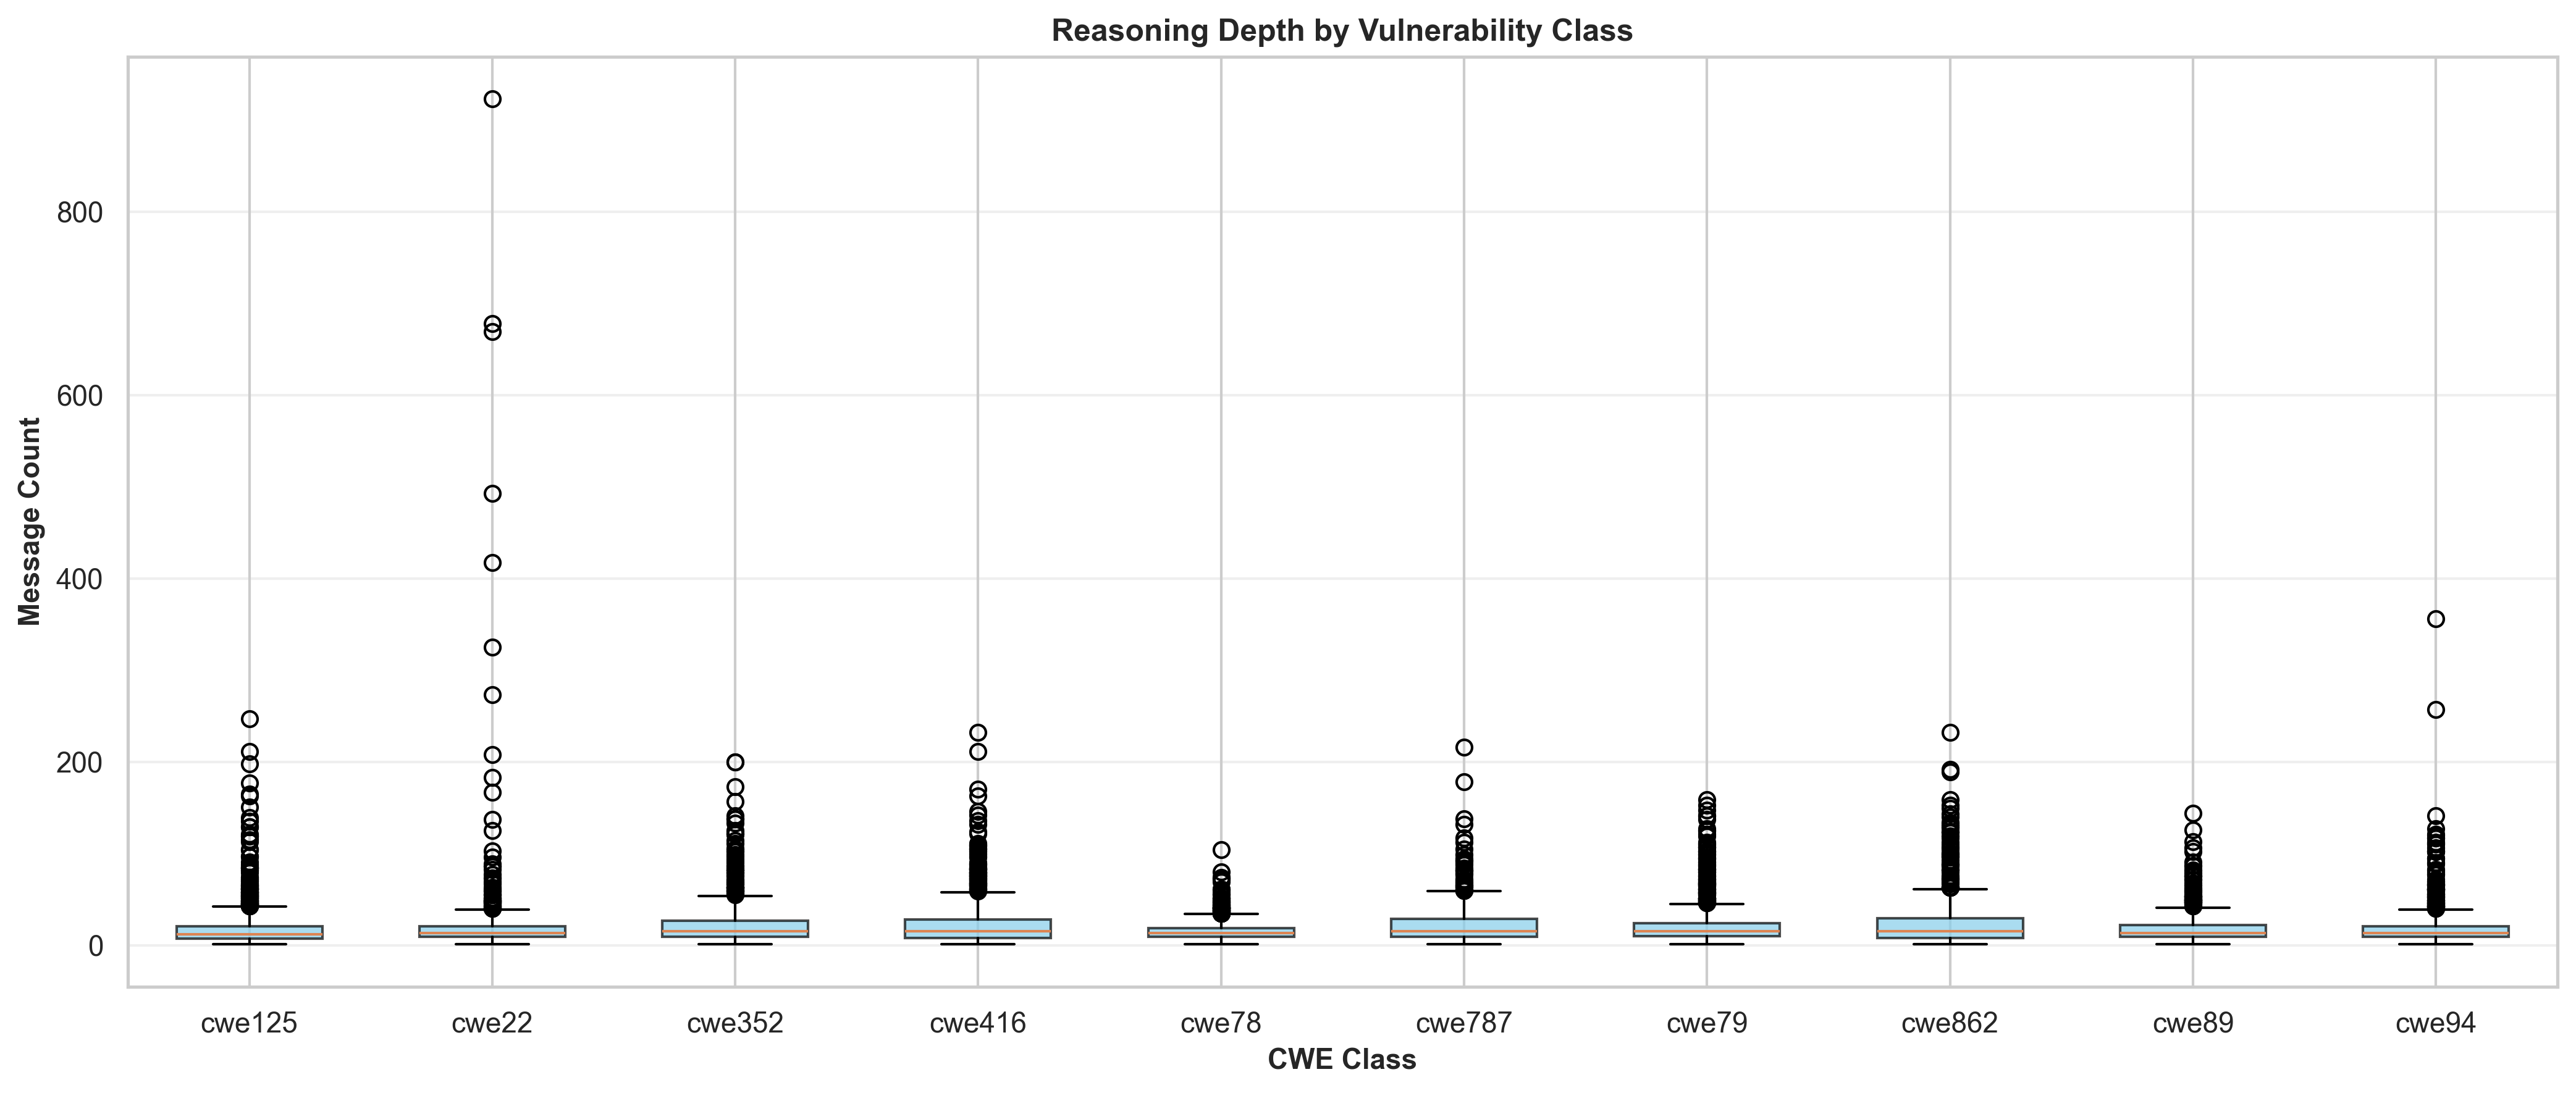

In [155]:
fig, ax = plt.subplots(figsize=(14, 6))

# Organize message counts by CWE
cwe_message_data = defaultdict(list)
for model_name, prompts in data["raw_samples"].items():
    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    cwe_message_data[cwe].append(sample["message_count"])

# Sort CWEs
cwes_sorted = sorted(cwe_message_data.keys())
cwe_data_list = [cwe_message_data[cwe] for cwe in cwes_sorted]

# Create box plot
bp = ax.boxplot(
    cwe_data_list,
    tick_labels=cwes_sorted,
    patch_artist=True,
    widths=0.6,
)

# Color boxes
for patch in bp["boxes"]:
    patch.set_facecolor("#87CEEB")
    patch.set_alpha(0.7)

ax.set_xlabel("CWE Class", fontsize=11, fontweight="bold")
ax.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax.set_title("Reasoning Depth by Vulnerability Class", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("7_message_count_by_cwe.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 7_message_count_by_cwe.png")
plt.show()

## Plot 3: Message Count Distribution Comparison (Frontier vs Baseline)

✓ Saved 8_message_count_distribution.png


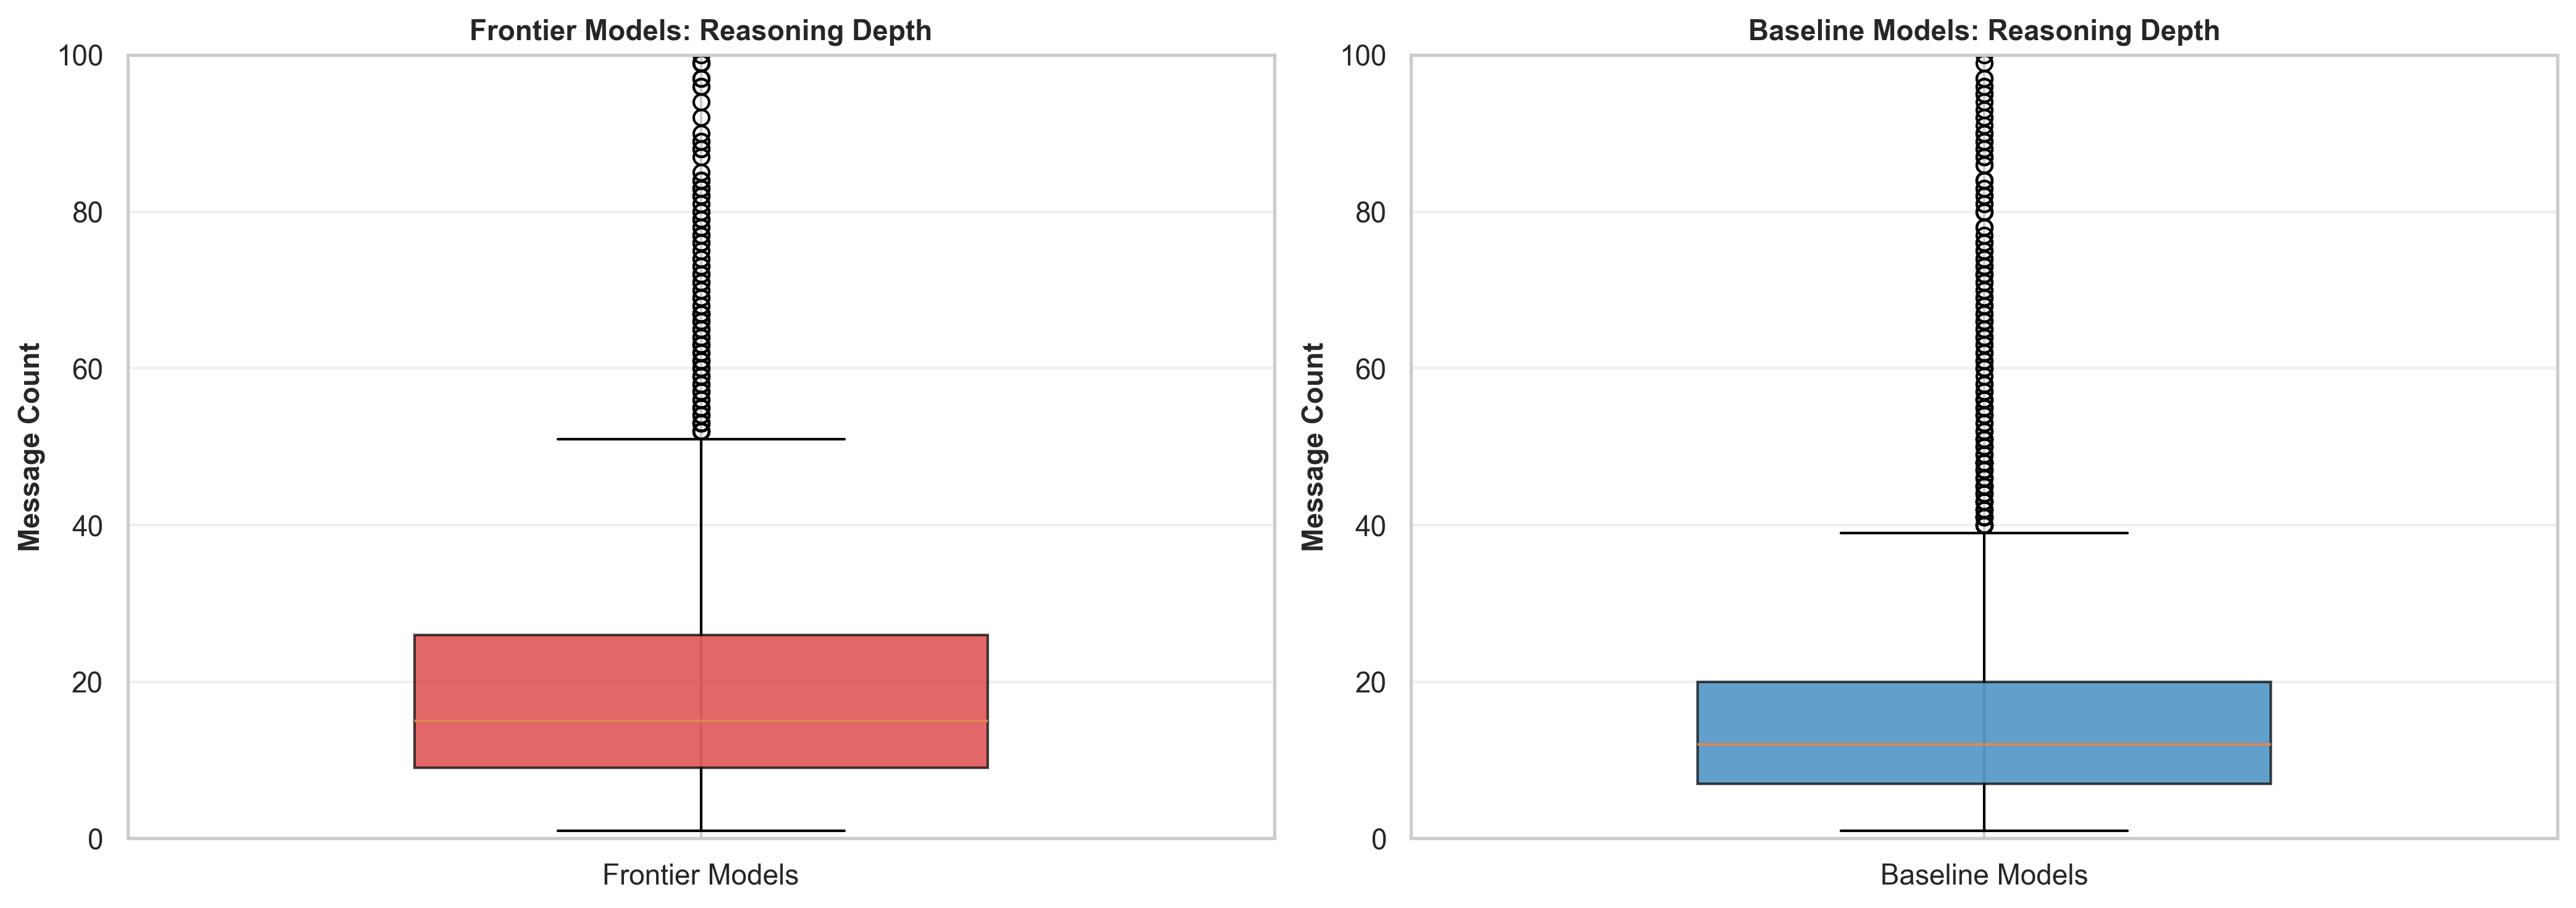

In [156]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

frontier_messages = []
baseline_messages = []

for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    if display_name not in frontier_models and display_name not in baseline_models:
        continue

    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    if display_name in frontier_models:
                        frontier_messages.append(sample["message_count"])
                    else:
                        baseline_messages.append(sample["message_count"])

# Frontier box plot
bp1 = ax1.boxplot(
    [frontier_messages],
    tick_labels=["Frontier Models"],
    patch_artist=True,
    widths=0.5,
)
for patch in bp1["boxes"]:
    patch.set_facecolor("#D62728")
    patch.set_alpha(0.7)

ax1.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax1.set_title("Frontier Models: Reasoning Depth", fontsize=11, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_ylim(0, 100)

# Baseline box plot
bp2 = ax2.boxplot(
    [baseline_messages],
    tick_labels=["Baseline Models"],
    patch_artist=True,
    widths=0.5,
)
for patch in bp2["boxes"]:
    patch.set_facecolor("#1F77B4")
    patch.set_alpha(0.7)

ax2.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax2.set_title("Baseline Models: Reasoning Depth", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("8_message_count_distribution.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 8_message_count_distribution.png")
plt.show()

✓ Saved 10_difficulty_vs_message_count.png


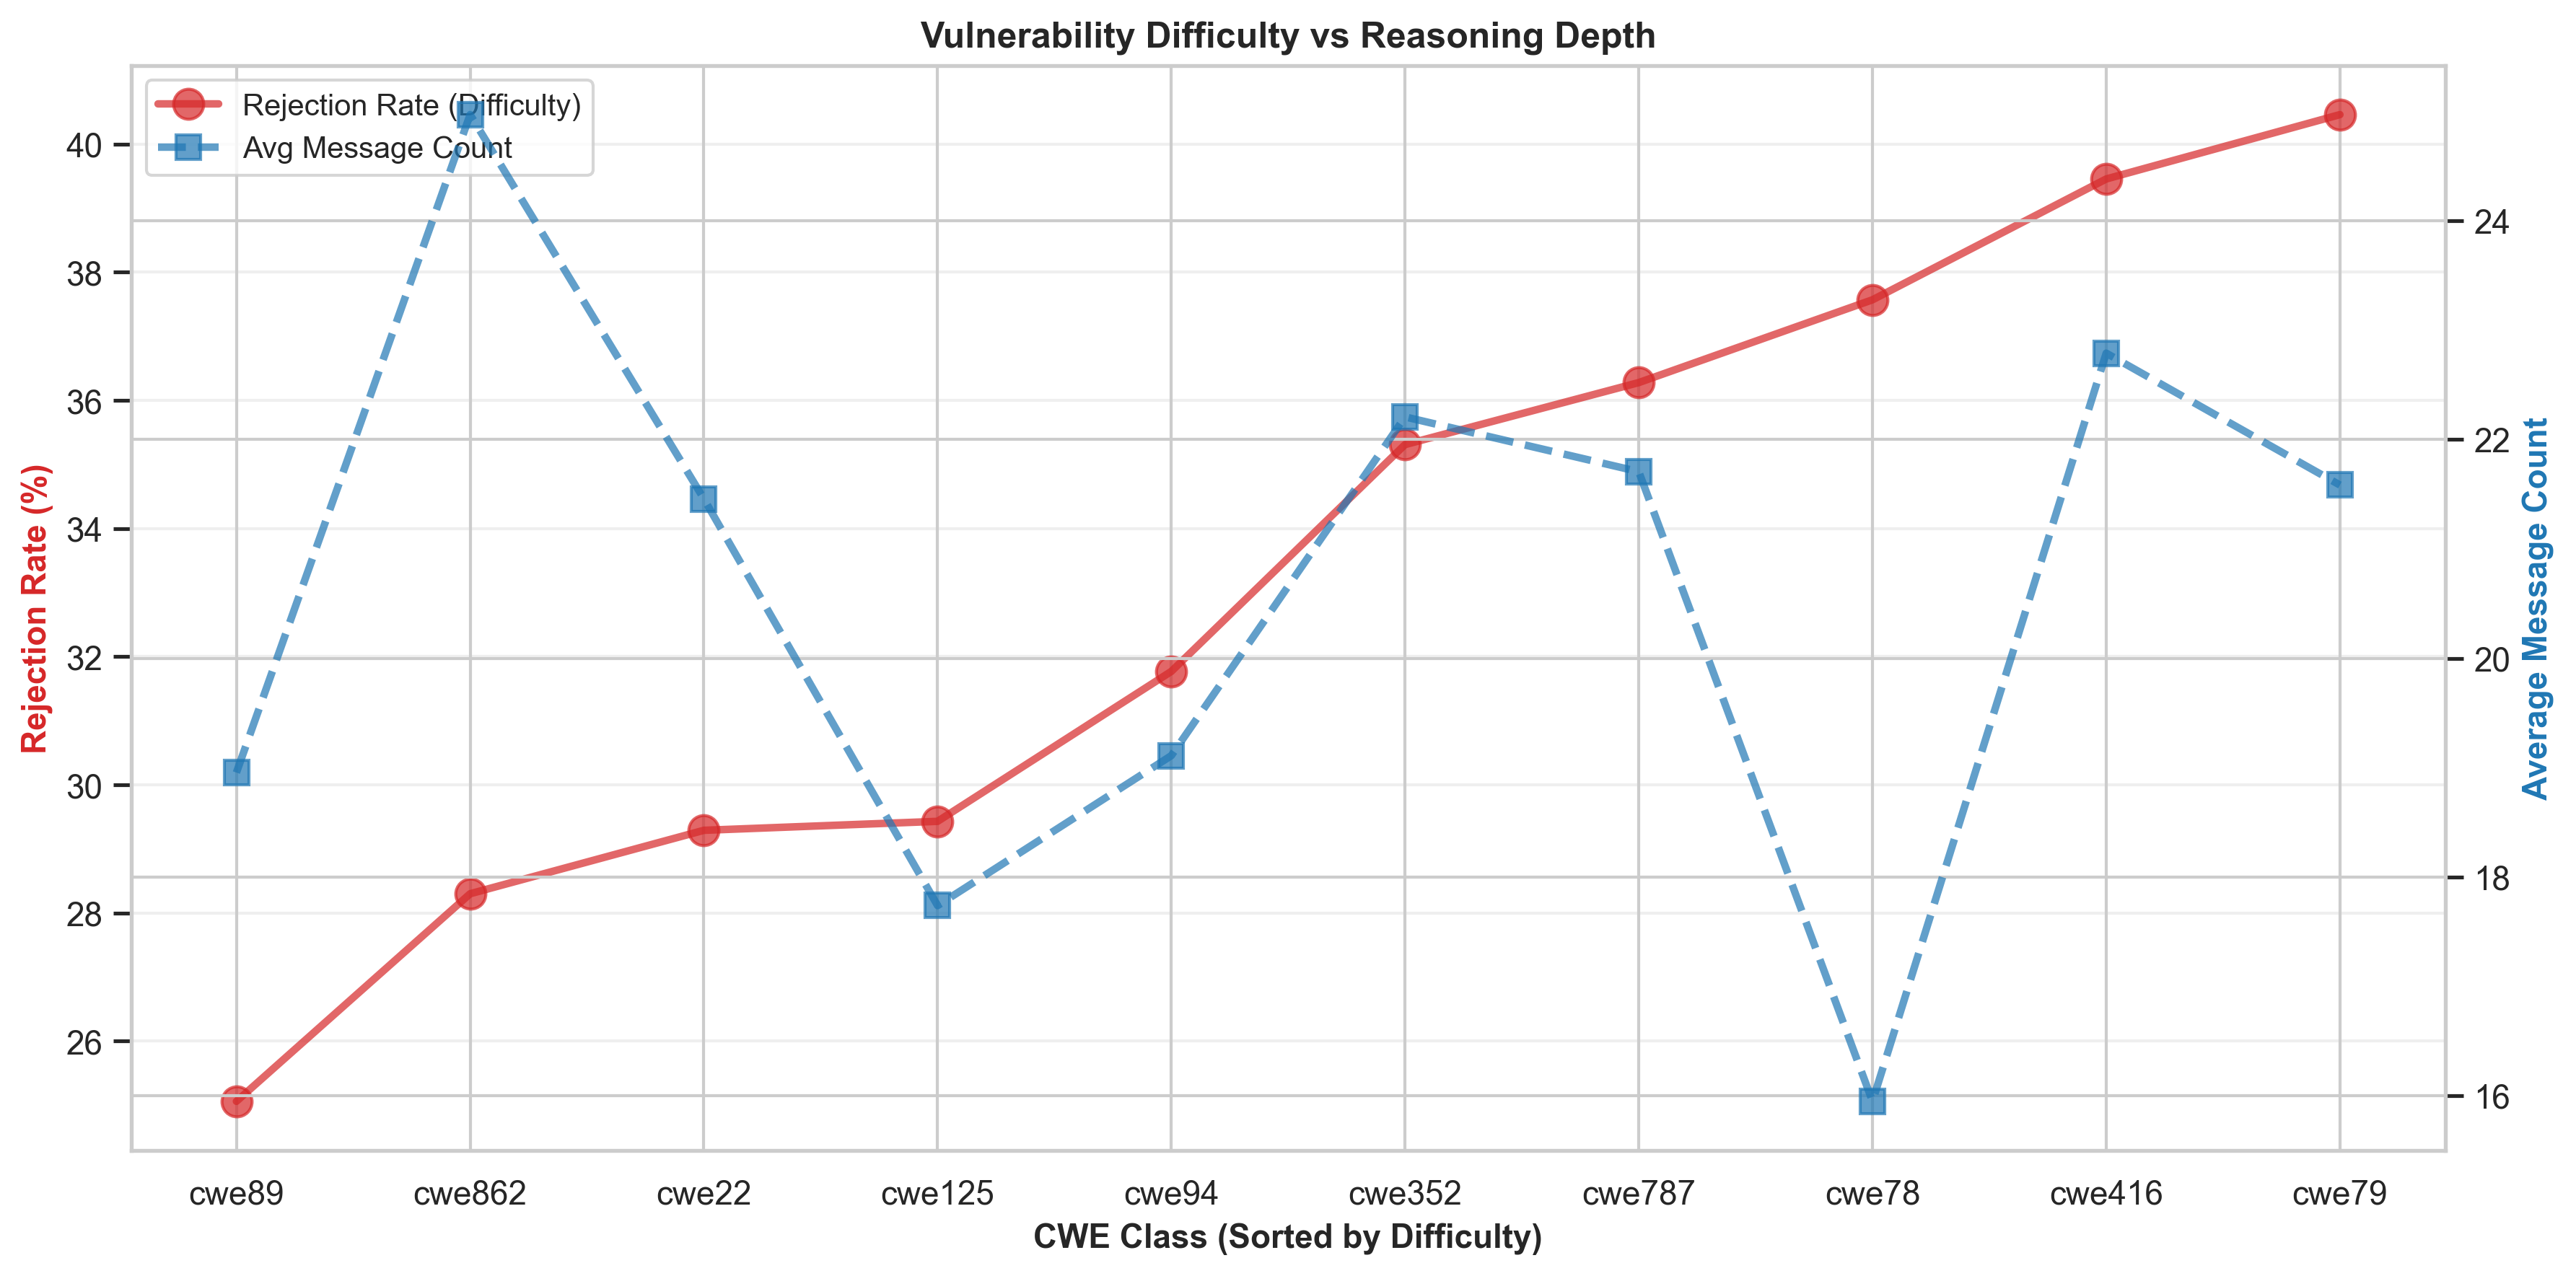

In [157]:
# Load NIPS results to get rejection rates
nips_path = Path("../nips_results_with_srr_retained_split.json")
try:
    with open(nips_path) as f:
        nips_data = json.load(f)
    
    fig, ax = plt.subplots(figsize=(12, 6))

    # Compute rejection rate per CWE and average message count
    cwe_rejection_rates = {}
    cwe_message_means = {}
    
    # First pass: get rejection rates from NIPS data
    for cwe in data["per_cwe"]:
        # Get average detection accuracy across all models for this CWE
        accuracies = []
        for model in nips_data["per_cwe"]:
            if "plain" in nips_data["per_cwe"][model]:
                if cwe in nips_data["per_cwe"][model]["plain"]:
                    da = nips_data["per_cwe"][model]["plain"][cwe].get("detection_accuracy", {}).get("accuracy")
                    if da is not None:
                        accuracies.append(da)
        
        if accuracies:
            avg_accuracy = np.mean(accuracies)
            rejection_rate = 100 - avg_accuracy
            cwe_rejection_rates[cwe] = rejection_rate
    
    # Second pass: get average message count for each CWE from raw samples
    for cwe in cwe_rejection_rates.keys():
        messages = []
        try:
            for model_name in data["raw_samples"]:
                if model_name not in data["raw_samples"]:
                    continue
                for prompt in data["raw_samples"][model_name]:
                    if prompt != "plain":
                        continue
                    if cwe not in data["raw_samples"][model_name][prompt]:
                        continue
                    for framing in data["raw_samples"][model_name][prompt][cwe]:
                        samples = data["raw_samples"][model_name][prompt][cwe][framing]
                        for sample in samples:
                            messages.append(sample["message_count"])
        except (KeyError, TypeError) as e:
            pass
        
        if messages:
            cwe_message_means[cwe] = np.mean(messages)
    
    # Sort by rejection rate
    cwes_sorted = sorted(cwe_rejection_rates.keys(), key=lambda c: cwe_rejection_rates[c])
    rejection_rates = [cwe_rejection_rates[c] for c in cwes_sorted]
    message_means = [cwe_message_means.get(c, 0) for c in cwes_sorted]
    
    x_pos = np.arange(len(cwes_sorted))
    
    # Plot rejection rate (primary axis)
    ax.plot(x_pos, rejection_rates, 'o-', linewidth=2.5, markersize=10, 
            color="#D62728", alpha=0.7, label="Rejection Rate (Difficulty)")
    
    # Secondary axis for message count
    ax2 = ax.twinx()
    ax2.plot(x_pos, message_means, 's--', linewidth=2.5, markersize=8, 
            color="#1F77B4", alpha=0.7, label="Avg Message Count")
    
    ax.set_xlabel("CWE Class (Sorted by Difficulty)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Rejection Rate (%)", fontsize=11, fontweight="bold", color="#D62728")
    ax2.set_ylabel("Average Message Count", fontsize=11, fontweight="bold", color="#1F77B4")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cwes_sorted, rotation=0)
    ax.set_title("Vulnerability Difficulty vs Reasoning Depth", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    
    # Legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
    
    plt.tight_layout()
    plt.savefig("10_difficulty_vs_message_count.png", dpi=300, bbox_inches="tight", facecolor="white")
    print("✓ Saved 10_difficulty_vs_message_count.png")
    plt.show()
    
except Exception as e:
    print(f"⚠ Error generating plot: {type(e).__name__}: {e}")

fig, ax = plt.subplots(figsize=(14, 7))

# Organize message counts by model and CWE
model_cwe_messages = defaultdict(lambda: defaultdict(list))
for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    
    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    model_cwe_messages[display_name][cwe].append(sample["message_count"])

# Compute means per model and CWE
model_means = {}
for model in model_cwe_messages:
    model_means[model] = {}
    for cwe in model_cwe_messages[model]:
        model_means[model][cwe] = np.mean(model_cwe_messages[model][cwe])

# Sort CWEs
cwes_list = sorted(set(cwe for model_data in model_means.values() for cwe in model_data.keys()))
x_pos = np.arange(len(cwes_list))

# Colors for different model types
colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Plot lines for each model
for model in sorted(model_means.keys()):
    if model not in colors:
        continue
    
    messages = [model_means[model].get(cwe, 0) for cwe in cwes_list]
    
    # Different line styles for frontier vs baseline
    if model in frontier_models:
        ax.plot(x_pos, messages, 'o-', linewidth=2.5, markersize=7,
                color=colors[model], alpha=0.8, label=model)
    else:
        ax.plot(x_pos, messages, 's--', linewidth=2, markersize=6,
                color=colors[model], alpha=0.6, label=model)

ax.set_xlabel("CWE Class", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Message Count", fontsize=11, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(cwes_list, rotation=0)
ax.set_title("Message Count Trends Across Models and Vulnerabilities", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("11_message_count_trends_by_model.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 11_message_count_trends_by_model.png")
plt.show()

## Plot 4: Message Count by Framing Strategy (Line Plot with Dual Axis)

In [ ]:
# Create per-sample scatter plot
fig, ax = plt.subplots(figsize=(13, 7))

# Consistent color scheme
model_colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Plot each sample with transparency (excluding unwanted models)
for sample in all_samples:
    if sample['model'] in excluded_models:
        continue
    color = model_colors.get(sample['model'], '#999999')
    marker = 'o' if sample['detection'] == 1.0 else 'x'
    ax.scatter(sample['message_count'], sample['detection'] * 100, 
              s=30, alpha=0.15, color=color, marker=marker, linewidth=0.5)

# Add model legend (average points)
for model in sorted(set(s['model'] for s in all_samples if s['model'] not in excluded_models)):
    model_samples = [s for s in all_samples if s['model'] == model]
    avg_messages = np.mean([s['message_count'] for s in model_samples])
    avg_detection = np.mean([s['detection'] for s in model_samples]) * 100
    
    color = model_colors.get(model, '#999999')
    ax.scatter(avg_messages, avg_detection, s=300, alpha=0.8, color=color, 
              edgecolors='black', linewidth=2, label=model, zorder=5)

ax.set_xlabel("Message Count (Individual Samples)", fontsize=12, fontweight="bold")
ax.set_ylabel("Detection Result (%)", fontsize=12, fontweight="bold")
ax.set_title("(g) Per-Sample Message Count vs Detection Success", fontsize=12, fontweight="bold", loc='left')
ax.set_ylim(-5, 105)
ax.set_xlim(-2, min(100, max(s['message_count'] for s in all_samples) + 10))
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig("13_message_count_per_sample_scatter.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 13_message_count_per_sample_scatter.png")
plt.show()

In [ ]:
# Efficiency clustering analysis
fig, ax = plt.subplots(figsize=(13, 8))

# Consistent color scheme
model_colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

for sample in all_samples:
    if sample['model'] in excluded_models:
        continue
    color = model_colors.get(sample['model'], '#999999')
    marker = 'o' if sample['detection'] == 1.0 else 'x'
    ax.scatter(sample['message_count'], sample['detection'] * 100, 
              s=40, alpha=0.2, color=color, marker=marker, linewidth=0.5)

# Add quadrant regions
ax.axvline(x=20, color='gray', linestyle=':', alpha=0.4, linewidth=2)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.4, linewidth=2)

# Add quadrant labels
ax.text(10, 75, "Efficient\n(Low Effort, High Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(35, 75, "Thorough\n(High Effort, High Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(10, 25, "Quick Fails\n(Low Effort, Low Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))
ax.text(35, 25, "Struggling\n(High Effort, Low Success)", 
       ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# Add model average points
for model in sorted(set(s['model'] for s in all_samples if s['model'] not in excluded_models)):
    model_samples = [s for s in all_samples if s['model'] == model]
    avg_messages = np.mean([s['message_count'] for s in model_samples])
    avg_detection = np.mean([s['detection'] for s in model_samples]) * 100
    
    color = model_colors.get(model, '#999999')
    ax.scatter(avg_messages, avg_detection, s=350, alpha=0.9, color=color, 
              edgecolors='black', linewidth=2.5, label=model, zorder=10)

ax.set_xlabel("Message Count", fontsize=12, fontweight="bold")
ax.set_ylabel("Detection Success Rate (%)", fontsize=12, fontweight="bold")
ax.set_title("(h) Efficiency Clustering: Reasoning Patterns", fontsize=12, fontweight="bold", loc='left')
ax.set_xlim(-2, 50)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig("14_efficiency_clusters.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 14_efficiency_clusters.png")
plt.show()

In [ ]:
# Per-CWE efficiency analysis
fig, ax = plt.subplots(figsize=(14, 7))

# Consistent color scheme
model_colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Calculate efficiency metrics per CWE per model
cwe_efficiency = defaultdict(lambda: {})

for model in set(s['model'] for s in all_samples if s['model'] not in excluded_models):
    for cwe in set(s['cwe'] for s in all_samples):
        model_cwe_samples = [s for s in all_samples if s['model'] == model and s['cwe'] == cwe]
        
        if model_cwe_samples:
            avg_messages = np.mean([s['message_count'] for s in model_cwe_samples])
            detection_rate = np.mean([s['detection'] for s in model_cwe_samples]) * 100
            efficiency = detection_rate / avg_messages if avg_messages > 0 else 0
            
            cwe_efficiency[model][cwe] = {
                'messages': avg_messages,
                'detection': detection_rate,
                'efficiency': efficiency,
                'n_samples': len(model_cwe_samples)
            }

# Sort CWEs by average difficulty
cwes_list = sorted(set(s['cwe'] for s in all_samples))
cwe_difficulty = {}
for cwe in cwes_list:
    all_cwe_samples = [s for s in all_samples if s['cwe'] == cwe]
    cwe_difficulty[cwe] = np.mean([s['detection'] for s in all_cwe_samples]) * 100

cwes_sorted = sorted(cwes_list, key=lambda c: cwe_difficulty[c], reverse=True)

# Plot efficiency per CWE per model
x_pos = np.arange(len(cwes_sorted))
models_to_plot = sorted(set(s['model'] for s in all_samples if s['model'] not in excluded_models))

for model in models_to_plot:
    efficiencies = []
    for cwe in cwes_sorted:
        if model in cwe_efficiency and cwe in cwe_efficiency[model]:
            efficiencies.append(cwe_efficiency[model][cwe]['efficiency'])
        else:
            efficiencies.append(0)
    
    is_frontier = model in frontier_models
    linestyle = '-' if is_frontier else '--'
    marker = 'o' if is_frontier else 's'
    
    ax.plot(x_pos, efficiencies, marker=marker, linestyle=linestyle, 
           linewidth=2.5, markersize=8, label=model, 
           color=model_colors.get(model, '#999999'), alpha=0.8)

ax.set_xlabel("CWE (Sorted by Detection Difficulty)", fontsize=12, fontweight="bold")
ax.set_ylabel("Efficiency (Detection Rate / Message Count)", fontsize=12, fontweight="bold")
ax.set_title("(i) Per-CWE Efficiency: How Well Models Reason About Each Vulnerability", 
            fontsize=12, fontweight="bold", loc='left')
ax.set_xticks(x_pos)
ax.set_xticklabels([c.upper() for c in cwes_sorted], rotation=0)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig("15_per_cwe_efficiency.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 15_per_cwe_efficiency.png")
plt.show()